In [ ]:
%cd /content
!cat SemArt_subset.zip.part* > SemArt_subset.zip
!ls -lh SemArt_subset.zip

/content
-rw-r--r-- 1 root root 2.7G Mar  8 09:50 SemArt_subset.zip


In [ ]:
!mkdir -p /content/semart_subset
!unzip -q /content/SemArt_subset.zip -d /content/semart_subset
!echo "Numero file estratti:"
!find /content/semart_subset -type f | wc -l
!ls /content/semart_subset | head

Numero file estratti:
18293
SemArt_subset


In [ ]:
%cd /content
!rm -f SemArt_subset.zip.part*
!rm -f SemArt_subset.zip
!ls -lh | head

/content
total 996K
-rw-r--r-- 1 root root 983K Mar  8 09:47 artquest_second_prompt_READY.csv
drwx------ 5 root root 4.0K Mar  8 09:03 drive
drwxr-xr-x 1 root root 4.0K Jan 16 14:24 sample_data
drwxr-xr-x 3 root root 4.0K Mar  8 09:50 semart_subset


In [ ]:
import os

MODEL_TAG = "gemini_artquest_secondprompt_v2"
OUT_DIR = f"/content/runs/{MODEL_TAG}"

os.makedirs(OUT_DIR, exist_ok=True)

print("Cartella creata in:", OUT_DIR)

Cartella creata in: /content/runs/gemini_artquest_secondprompt_v2


In [ ]:
import pandas as pd


ARTQUEST_CSV = "/content/artquest_train_tech8_only.csv"

df = pd.read_csv(ARTQUEST_CSV)
print("Righe totali (domande):", len(df))
print("Colonne:", list(df.columns))

works_df = df.drop_duplicates("image")[["image"]].copy()
if "technique_macro" in df.columns:
    works_df = df.drop_duplicates("image")[["image","technique_macro"]].copy()

print("Opere uniche:", len(works_df))
works_df.head()

Righe totali (domande): 109758
Colonne: ['image', 'question', 'answer', 'question_type', 'answer_norm', 'answer_closed', 'technique_macro']
Opere uniche: 18293


,image,technique_macro
0,19873-1darmst.jpg,NaN
6,18759-guard301.jpg,NaN
12,04589-temptati.jpg,NaN
18,36582-paolo_f1.jpg,NaN
24,00930-30coron.jpg,NaN


In [ ]:
import os

SEMART_DIR = "/content/semart_subset/SemArt_subset"
assert os.path.exists(SEMART_DIR), SEMART_DIR

run_df = works_df.copy()
run_df["file_path"] = run_df["image"].apply(lambda x: os.path.join(SEMART_DIR, str(x)))

# controlli
missing = (~run_df["file_path"].apply(os.path.exists)).sum()
print("Missing file_path:", missing, "/", len(run_df))

run_df = run_df[run_df["file_path"].apply(os.path.exists)].reset_index(drop=True)
print("Righe finali:", len(run_df))
run_df.head()

NameError: name 'works_df' is not defined

In [ ]:
run_df_full = run_df.copy()
print("Totale full:", len(run_df_full))

Totale full: 18293


In [ ]:
!pip -q install -U google-genai pillow

import os
from getpass import getpass

os.environ["GEMINI_API_KEY"] = getpass("Incolla Gemini API key:")

Incolla Gemini API key:··········


In [ ]:
from google import genai

client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])
print("Gemini client pronto")

Gemini client pronto


In [ ]:
import os, json


N_OPERE = 990

out_jsonl = "/content/gemini_identification_artquest.jsonl"


done = set()
if os.path.exists(out_jsonl):
    with open(out_jsonl, "r", encoding="utf-8") as f:
        for line in f:
            try:
                r = json.loads(line)
                if r.get("file_path"):
                    done.add(r["file_path"])
            except:
                pass

print("Già fatte:", len(done))

#  non ancora analizzate
run_df_new = run_df_full[~run_df_full["file_path"].isin(done)].copy()

print("Ancora disponibili:", len(run_df_new))

#  N_OPERE
run_df = run_df_new.head(N_OPERE).copy()

print("Ora analizzo:", len(run_df), "opere")

Già fatte: 17303
Ancora disponibili: 990
Ora analizzo: 990 opere


In [ ]:
import os, json, time, random
from datetime import datetime
import pandas as pd
from google import genai
from google.genai import types
from tqdm import tqdm

assert os.environ.get("GEMINI_API_KEY"), "GEMINI_API_KEY non impostata. Esegui prima la cella con getpass()."

client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])

PROMPT = """Analyze the image.

Can you identify this artwork as a specific known work?

If YES, provide the artist name and artwork title.
If NO, say it is not identified.

Return ONLY this JSON:
{
  "identified": true | false,
  "artist_name": "artist name or null",
  "artwork_title": "artwork title or null"
}

Rules:
- Answer YES only if you believe this is a specific known artwork.
- If unsure, answer NO.
- Do not provide any additional description or explanation.
"""

MODEL_NAME = "models/gemini-2.5-flash"
MIN_SECONDS_BETWEEN_CALLS = 0.4

def guess_mime(path: str) -> str:
    p = path.lower()
    if p.endswith(".png"): return "image/png"
    if p.endswith(".webp"): return "image/webp"
    return "image/jpeg"

def safe_json(text):
    import re
    s = str(text).strip()
    s = re.sub(r"^```(?:json)?\s*", "", s)
    s = re.sub(r"\s*```$", "", s)
    try:
        return json.loads(s)
    except:
        return None

def generate_with_retry(img_bytes: bytes, mime: str, max_retries: int = 6):
    image_part = types.Part.from_bytes(data=img_bytes, mime_type=mime)
    last = None
    for attempt in range(max_retries):
        try:
            resp = client.models.generate_content(model=MODEL_NAME, contents=[PROMPT, image_part])
            return True, resp.text, None
        except Exception as e:
            msg = repr(e); last = msg
            is_503 = ("503" in msg) or ("UNAVAILABLE" in msg) or ("overloaded" in msg.lower())
            is_429 = ("429" in msg) or ("RESOURCE_EXHAUSTED" in msg) or ("quota" in msg.lower())
            if not (is_503 or is_429):
                return False, None, msg
            wait = MIN_SECONDS_BETWEEN_CALLS * (2 ** min(attempt, 3))
            wait = min(wait, 120) + random.uniform(0, 2)
            print(f"Retry {attempt+1}/{max_retries} tra {wait:.1f}s | {msg[:120]}")
            time.sleep(wait)
    return False, None, f"Max retries reached: {last}"

OUT_DIR = "/content"
os.makedirs(OUT_DIR, exist_ok=True)
out_jsonl = os.path.join(OUT_DIR, "gemini_identification_artquest.jsonl")

# resume
done = set()
if os.path.exists(out_jsonl):
    with open(out_jsonl, "r", encoding="utf-8") as f:
        for line in f:
            try:
                r = json.loads(line)
                done.add(r.get("file_path"))
            except:
                pass
print("Gia fatte:", len([x for x in done if x]))

last_call_time = 0
new_done = 0

for i, row in tqdm(run_df.iterrows(), total=len(run_df)):
    file_path = row["file_path"]
    if file_path in done:
        continue

    rec = {
        "i": int(i),
        "image": row.get("image"),
        "file_path": file_path,
        "timestamp": datetime.utcnow().isoformat() + "Z",
        "model": MODEL_NAME,
        "ok": False,
        "error": None,
        "response_text": None,
        "identified": None,
        "pred_artist": None,
        "pred_title": None,
    }

    elapsed = time.time() - last_call_time
    if elapsed < MIN_SECONDS_BETWEEN_CALLS:
        time.sleep(MIN_SECONDS_BETWEEN_CALLS - elapsed + random.uniform(0, 0.2))

    try:
        with open(file_path, "rb") as f:
            img_bytes = f.read()

        ok, text, err = generate_with_retry(img_bytes, guess_mime(file_path))
        rec["ok"] = ok
        rec["response_text"] = text
        rec["error"] = err

        if ok and text:
            data = safe_json(text)
            if data is None:
                rec["ok"] = False
                rec["error"] = "JSON parse failed"
            else:
                rec["identified"] = data.get("identified")
                rec["pred_artist"] = data.get("artist_name")
                rec["pred_title"] = data.get("artwork_title")

    except Exception as e:
        rec["error"] = repr(e)

    last_call_time = time.time()

    with open(out_jsonl, "a", encoding="utf-8") as f:
        f.write(json.dumps(rec, ensure_ascii=False) + "\n")

    done.add(file_path)
    new_done += 1

    if new_done % 10 == 0:
        print(f"+{new_done} nuove | ok={rec['ok']} | {row.get('image')}")
        if not rec["ok"]:
            print("  ERRORE:", rec["error"])

print("FINITO. Nuove analizzate:", new_done)
print("JSONL salvato in:", out_jsonl)

Gia fatte: 17303


  0%|          | 0/990 [00:00<?, ?it/s]/tmp/ipython-input-250/470531130.py:98: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat() + "Z",
  1%|          | 10/990 [01:00<1:22:16,  5.04s/it]

+10 nuove | ok=True | 02830-icescene.jpg


  2%|▏         | 20/990 [01:41<1:00:46,  3.76s/it]

+20 nuove | ok=True | 19919-06ladyri.jpg


...

+970 nuove | ok=True | 11298-319delac.jpg


 99%|█████████▉| 980/990 [1:13:31<00:46,  4.69s/it]

+980 nuove | ok=True | 22729-3death.jpg


100%|██████████| 990/990 [1:14:29<00:00,  4.52s/it]

+990 nuove | ok=True | 35847-fishingb.jpg
FINITO. Nuove analizzate: 990
JSONL salvato in: /content/gemini_identification_artquest.jsonl


In [ ]:
import json
import pandas as pd
import os

OUT_DIR = "/content"
out_jsonl = os.path.join(OUT_DIR, "gemini_identification_artquest.jsonl")
out_csv   = os.path.join(OUT_DIR, "gemini_identification_artquest.csv")

rows = []

with open(out_jsonl, "r", encoding="utf-8") as f:
    for line in f:
        try:
            rows.append(json.loads(line))
        except:
            pass

df_out = pd.DataFrame(rows)

print("Totale righe nel JSONL:", len(df_out))

df_out.to_csv(out_csv, index=False)

print("CSV salvato in:", out_csv)
df_out.head()

Totale righe nel JSONL: 18293
CSV salvato in: /content/gemini_identification_artquest.csv


,i,image,file_path,timestamp,model,ok,error,response_text,identified,pred_artist,pred_title
0,0,19873-1darmst.jpg,/content/semart_subset/SemArt_subset/19873-1da...,2026-02-26T17:23:48.159244Z,models/gemini-2.5-flash,True,None,"```json\n{\n ""identified"": true,\n ""artist_n...",True,Jan van Eyck,The Virgin and Child with Canon Joris van der ...
1,1,18759-guard301.jpg,/content/semart_subset/SemArt_subset/18759-gua...,2026-02-26T17:23:52.621957Z,models/gemini-2.5-flash,True,None,"```json\n{\n ""identified"": true,\n ""artist_n...",True,Francesco Guardi,Capriccio with a Ruined Arch and a Tent
2,2,04589-temptati.jpg,/content/semart_subset/SemArt_subset/04589-tem...,2026-02-26T17:23:56.008366Z,models/gemini-2.5-flash,True,None,"```json\n{\n ""identified"": true,\n ""artist_n...",True,Annibale Carracci,Rinaldo and Armida
3,3,36582-paolo_f1.jpg,/content/semart_subset/SemArt_subset/36582-pao...,2026-02-26T17:23:59.315291Z,models/gemini-2.5-flash,True,None,"```json\n{\n ""identified"": true,\n ""artist_n...",True,Henry Fuseli,Paolo and Francesca
4,4,00930-30coron.jpg,/content/semart_subset/SemArt_subset/00930-30c...,2026-02-26T17:24:06.301730Z,models/gemini-2.5-flash,True,None,"```json\n{\n ""identified"": true,\n ""artist_n...",True,Fra Angelico,The Coronation of the Virgin


In [ ]:
import pandas as pd
import numpy as np

# file originali
artquest_csv = "/content/artquest_train_tech8_only.csv"
gemini_csv   = "/content/gemini_identification_artquest.csv"

df_true = pd.read_csv(artquest_csv)
df_pred = pd.read_csv(gemini_csv)

print("ArtQuest rows:", len(df_true))
print("Gemini rows:", len(df_pred))

df_true.head()

ArtQuest rows: 109758
Gemini rows: 18293


,image,question,answer,question_type,answer_norm,answer_closed,technique_macro
0,19873-1darmst.jpg,how is the painting called,Darmstadt Madonna,title,Darmstadt Madonna,Darmstadt Madonna,NaN
1,19873-1darmst.jpg,what school does the painting represent,German,school,german,german,NaN
2,19873-1darmst.jpg,during which period was the painting created,1501-1550,timeframe,1501-1550,1501-1550,NaN
3,19873-1darmst.jpg,who is the artist behind the artwork,Hans the Younger HOLBEIN,artist,Hans the Younger HOLBEIN,Hans the Younger HOLBEIN,NaN
4,19873-1darmst.jpg,what is the painting's genre,religious,type,religious,religious,NaN


In [ ]:
# prendo solo domanda artista
true_artists = df_true[df_true["question_type"] == "artist"].copy()

# solo image + answer
true_artists = true_artists[["image", "answer"]].rename(
    columns={"answer": "true_artist"}
)

print("Numero opere uniche:", true_artists["image"].nunique())
true_artists.head()

Numero opere uniche: 18293


,image,true_artist
3,19873-1darmst.jpg,Hans the Younger HOLBEIN
9,18759-guard301.jpg,Francesco GUARDI
15,04589-temptati.jpg,Giovanni BILIVERT
21,36582-paolo_f1.jpg,Ary SCHEFFER
27,00930-30coron.jpg,Fra ANGELICO


In [ ]:
df_pred["image"] = df_pred["file_path"].apply(lambda x: x.split("/")[-1])

df_pred.head()

,i,image,file_path,timestamp,model,ok,error,response_text,identified,pred_artist,pred_title
0,0,19873-1darmst.jpg,/content/semart_subset/SemArt_subset/19873-1da...,2026-02-26T17:23:48.159244Z,models/gemini-2.5-flash,True,NaN,"```json\n{\n ""identified"": true,\n ""artist_n...",True,Jan van Eyck,The Virgin and Child with Canon Joris van der ...
1,1,18759-guard301.jpg,/content/semart_subset/SemArt_subset/18759-gua...,2026-02-26T17:23:52.621957Z,models/gemini-2.5-flash,True,NaN,"```json\n{\n ""identified"": true,\n ""artist_n...",True,Francesco Guardi,Capriccio with a Ruined Arch and a Tent
2,2,04589-temptati.jpg,/content/semart_subset/SemArt_subset/04589-tem...,2026-02-26T17:23:56.008366Z,models/gemini-2.5-flash,True,NaN,"```json\n{\n ""identified"": true,\n ""artist_n...",True,Annibale Carracci,Rinaldo and Armida
3,3,36582-paolo_f1.jpg,/content/semart_subset/SemArt_subset/36582-pao...,2026-02-26T17:23:59.315291Z,models/gemini-2.5-flash,True,NaN,"```json\n{\n ""identified"": true,\n ""artist_n...",True,Henry Fuseli,Paolo and Francesca
4,4,00930-30coron.jpg,/content/semart_subset/SemArt_subset/00930-30c...,2026-02-26T17:24:06.301730Z,models/gemini-2.5-flash,True,NaN,"```json\n{\n ""identified"": true,\n ""artist_n...",True,Fra Angelico,The Coronation of the Virgin


In [ ]:
merged = df_pred.merge(true_artists, on="image", how="left")

print("Numero opere nel merge:", len(merged))
merged.head()

Numero opere nel merge: 18293


,i,image,file_path,timestamp,model,ok,error,response_text,identified,pred_artist,pred_title,true_artist
0,0,19873-1darmst.jpg,/content/semart_subset/SemArt_subset/19873-1da...,2026-02-26T17:23:48.159244Z,models/gemini-2.5-flash,True,NaN,"```json\n{\n ""identified"": true,\n ""artist_n...",True,Jan van Eyck,The Virgin and Child with Canon Joris van der ...,Hans the Younger HOLBEIN
1,1,18759-guard301.jpg,/content/semart_subset/SemArt_subset/18759-gua...,2026-02-26T17:23:52.621957Z,models/gemini-2.5-flash,True,NaN,"```json\n{\n ""identified"": true,\n ""artist_n...",True,Francesco Guardi,Capriccio with a Ruined Arch and a Tent,Francesco GUARDI
2,2,04589-temptati.jpg,/content/semart_subset/SemArt_subset/04589-tem...,2026-02-26T17:23:56.008366Z,models/gemini-2.5-flash,True,NaN,"```json\n{\n ""identified"": true,\n ""artist_n...",True,Annibale Carracci,Rinaldo and Armida,Giovanni BILIVERT
3,3,36582-paolo_f1.jpg,/content/semart_subset/SemArt_subset/36582-pao...,2026-02-26T17:23:59.315291Z,models/gemini-2.5-flash,True,NaN,"```json\n{\n ""identified"": true,\n ""artist_n...",True,Henry Fuseli,Paolo and Francesca,Ary SCHEFFER
4,4,00930-30coron.jpg,/content/semart_subset/SemArt_subset/00930-30c...,2026-02-26T17:24:06.301730Z,models/gemini-2.5-flash,True,NaN,"```json\n{\n ""identified"": true,\n ""artist_n...",True,Fra Angelico,The Coronation of the Virgin,Fra ANGELICO


In [ ]:
print("Identified value counts:")
print(merged["identified"].value_counts())

Identified value counts:
identified
True     18222
False       34
Name: count, dtype: int64


In [ ]:
identified_df = merged[merged["identified"] == True].copy()

print("Opere riconosciute:", len(identified_df))

Opere riconosciute: 18222


In [ ]:
import re
import unicodedata

def normalize_name(name):
    if pd.isna(name):
        return ""

    name = str(name).lower()
    name = unicodedata.normalize("NFKD", name)
    name = name.encode("ascii", "ignore").decode("utf-8")
    name = re.sub(r"[^\w\s]", "", name)
    name = re.sub(r"\s+", " ", name).strip()

    return name

identified_df["true_norm"] = identified_df["true_artist"].apply(normalize_name)
identified_df["pred_norm"] = identified_df["pred_artist"].apply(normalize_name)

In [ ]:
identified_df["match_exact"] = (
    identified_df["true_norm"] == identified_df["pred_norm"]
)

accuracy_exact = identified_df["match_exact"].mean() * 100

print(f"Accuracy esatta normalizzata: {accuracy_exact:.2f}%")

Accuracy esatta normalizzata: 23.58%


In [ ]:
!pip install -q rapidfuzz
from rapidfuzz import fuzz

def fuzzy_match(a, b, threshold=88):
    if not a or not b:
        return False
    return fuzz.token_sort_ratio(a, b) >= threshold

identified_df["match_fuzzy"] = identified_df.apply(
    lambda row: fuzzy_match(row["true_norm"], row["pred_norm"]),
    axis=1
)

accuracy_fuzzy = identified_df["match_fuzzy"].mean() * 100

print(f"Accuracy fuzzy (>=88): {accuracy_fuzzy:.2f}%")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 22.6 MB/s eta 0:00:00
Accuracy fuzzy (>=88): 26.31%


In [ ]:
total = len(merged)
identified = len(identified_df)
false_count = (merged["identified"] == False).sum()
correct = identified_df["match_fuzzy"].sum()

print("Totale opere analizzate:", total)
print("Riconosciute:", identified)
print("Non riconosciute:", false_count)
print("Artista corretto (fuzzy):", correct)

print("\nRecall riconoscimento:", round(identified/total*100,2), "%")
print("Accuracy artista (tra quelle riconosciute):", round(correct/identified*100,2), "%")
print("Accuracy totale sistema:", round(correct/total*100,2), "%")

Totale opere analizzate: 18293
Riconosciute: 18222
Non riconosciute: 34
Artista corretto (fuzzy): 4795

Recall riconoscimento: 99.61 %
Accuracy artista (tra quelle riconosciute): 26.31 %
Accuracy totale sistema: 26.21 %


In [ ]:
wrong_artist = identified_df[identified_df["match_fuzzy"] == False]

second_prompt_df = pd.concat([
    merged[merged["identified"] == False],
    wrong_artist
])

print("Opere per secondo prompt:", len(second_prompt_df))

second_prompt_df.to_csv("/content/artquest_second_prompt_dataset.csv", index=False)

print("File salvato.")

Opere per secondo prompt: 13461
File salvato.


In [ ]:
import pandas as pd

second_path = "artquest_second_prompt_dataset.csv"
df2 = pd.read_csv(second_path)

print("Righe:", len(df2))
print("Colonne:", list(df2.columns))
df2.head()

Righe: 13461
Colonne: ['i', 'image', 'file_path', 'timestamp', 'model', 'ok', 'error', 'response_text', 'identified', 'pred_artist', 'pred_title', 'true_artist', 'true_norm', 'pred_norm', 'match_exact', 'match_fuzzy']


,i,image,file_path,timestamp,model,ok,error,response_text,identified,pred_artist,pred_title,true_artist,true_norm,pred_norm,match_exact,match_fuzzy
0,739,19337-14july.jpg,/content/semart_subset/SemArt_subset/19337-14j...,2026-02-26T19:09:22.766206Z,models/gemini-2.5-flash,True,NaN,"```json\n{\n ""identified"": false,\n ""artist_...",False,NaN,NaN,Childe HASSAM,NaN,NaN,NaN,NaN
1,1418,44058-8ambierl.jpg,/content/semart_subset/SemArt_subset/44058-8am...,2026-02-26T20:03:59.409470Z,models/gemini-2.5-flash,True,NaN,"```json\n{\n ""identified"": false,\n ""artist_...",False,NaN,NaN,Rogier van der WEYDEN,NaN,NaN,NaN,NaN
2,2442,38936-14abraha.jpg,/content/semart_subset/SemArt_subset/38936-14a...,2026-02-26T21:25:02.396917Z,models/gemini-2.5-flash,True,NaN,"```json\n{\n ""identified"": false,\n ""artist_...",False,NaN,NaN,Giovanni Battista TIEPOLO,NaN,NaN,NaN,NaN
3,2900,43355-ambrose.jpg,/content/semart_subset/SemArt_subset/43355-amb...,2026-02-26T22:00:49.784542Z,models/gemini-2.5-flash,True,NaN,"```json\n{\n ""identified"": false,\n ""artist_...",False,NaN,NaN,Alvise VIVARINI,NaN,NaN,NaN,NaN
4,4160,23980-sanluca3.jpg,/content/semart_subset/SemArt_subset/23980-san...,2026-02-26T23:40:57.191275Z,models/gemini-2.5-flash,True,NaN,"```json\n{\n ""identified"": false,\n ""artist_...",False,NaN,NaN,Andrea MANTEGNA,NaN,NaN,NaN,NaN


In [ ]:
artquest_csv = "/content/artquest_train_tech8_only.csv"
df_true = pd.read_csv(artquest_csv)

print("Righe originali:", len(df_true))
print("Colonne originali:", list(df_true.columns))
df_true.head()

Righe originali: 109758
Colonne originali: ['image', 'question', 'answer', 'question_type', 'answer_norm', 'answer_closed', 'technique_macro']


,image,question,answer,question_type,answer_norm,answer_closed,technique_macro
0,19873-1darmst.jpg,how is the painting called,Darmstadt Madonna,title,Darmstadt Madonna,Darmstadt Madonna,NaN
1,19873-1darmst.jpg,what school does the painting represent,German,school,german,german,NaN
2,19873-1darmst.jpg,during which period was the painting created,1501-1550,timeframe,1501-1550,1501-1550,NaN
3,19873-1darmst.jpg,who is the artist behind the artwork,Hans the Younger HOLBEIN,artist,Hans the Younger HOLBEIN,Hans the Younger HOLBEIN,NaN
4,19873-1darmst.jpg,what is the painting's genre,religious,type,religious,religious,NaN


In [ ]:
second_path = "artquest_second_prompt_dataset.csv"
df2 = pd.read_csv(second_path)

# Se image non esiste ma esiste file_path
if "image" not in df2.columns and "file_path" in df2.columns:
    df2["image"] = df2["file_path"].apply(lambda x: str(x).split("/")[-1])

print("Colonne df2:", df2.columns)
df2[["image"]].head()

Colonne df2: Index(['i', 'image', 'file_path', 'timestamp', 'model', 'ok', 'error',
       'response_text', 'identified', 'pred_artist', 'pred_title',
       'true_artist', 'true_norm', 'pred_norm', 'match_exact', 'match_fuzzy'],
      dtype='object')


,image
0,19337-14july.jpg
1,44058-8ambierl.jpg
2,38936-14abraha.jpg
3,43355-ambrose.jpg
4,23980-sanluca3.jpg


In [ ]:
artquest_csv = "/content/artquest_train_tech8_only.csv"
df_true = pd.read_csv(artquest_csv)

# prendiamo solo image technique_macro
df_tech = df_true[["image", "technique_macro"]].drop_duplicates()

print("Immagini con tecnica:", df_tech["image"].nunique())
df_tech.head()

Immagini con tecnica: 18293


,image,technique_macro
0,19873-1darmst.jpg,NaN
5,19873-1darmst.jpg,oil
6,18759-guard301.jpg,NaN
11,18759-guard301.jpg,oil
12,04589-temptati.jpg,NaN


In [ ]:
df2_tech = df2.merge(df_tech, on="image", how="left")

print("Righe merge:", len(df2_tech))
print("Tecniche NaN:", df2_tech["technique_macro"].isna().sum())

Righe merge: 26922
Tecniche NaN: 13461


In [ ]:
vc = df2_tech["technique_macro"].value_counts(dropna=False)
pct = (vc / len(df2_tech) * 100).round(2)

tech_table = pd.DataFrame({
    "count": vc,
    "percent": pct
})

tech_table

,count,percent
technique_macro,,
NaN,13461,50.00
oil,10036,37.28
fresco,1988,7.38
tempera,1305,4.85
pastel,56,0.21
watercolour,38,0.14
drawing,24,0.09
mixed,11,0.04
encaustic,3,0.01


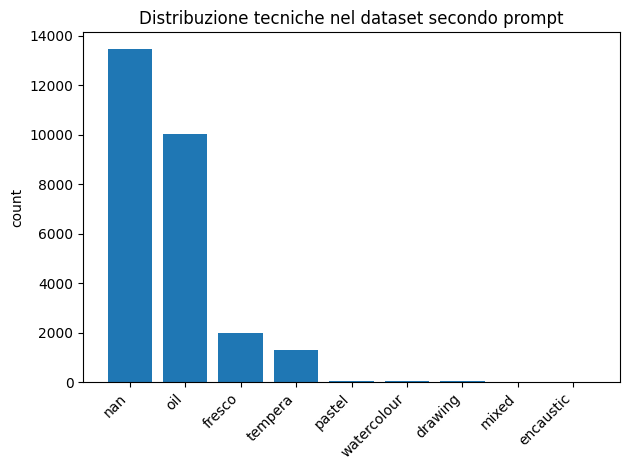

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(tech_table.index.astype(str), tech_table["count"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("count")
plt.title("Distribuzione tecniche nel dataset secondo prompt")
plt.tight_layout()
plt.show()

In [ ]:
df2_tech_clean = df2_tech[df2_tech["technique_macro"].notna()].copy()

print("Righe totali prima:", len(df2_tech))
print("Righe dopo filtro tecnica:", len(df2_tech_clean))

Righe totali prima: 26922
Righe dopo filtro tecnica: 13461


In [ ]:
vc = df2_tech_clean["technique_macro"].value_counts()
pct = (vc / len(df2_tech_clean) * 100).round(2)

tech_table_clean = pd.DataFrame({
    "count": vc,
    "percent": pct
})

tech_table_clean

,count,percent
technique_macro,,
oil,10036,74.56
fresco,1988,14.77
tempera,1305,9.69
pastel,56,0.42
watercolour,38,0.28
drawing,24,0.18
mixed,11,0.08
encaustic,3,0.02


In [ ]:
#togliamo title
df_no_title = df_true[df_true["question_type"] != "title"].copy()

# una riga per immagine
wide_meta = df_no_title.pivot_table(
    index="image",
    columns="question_type",
    values="answer_closed",
    aggfunc="first"
).reset_index()

print("Righe wide_meta:", len(wide_meta))
wide_meta.head()

Righe wide_meta: 18293


question_type,image,artist,school,technique,timeframe,type
0,00000-allegory.jpg,Hans von AACHEN,german,oil,1601-1650,mythological
1,00004-selfport.jpg,Hans von AACHEN,german,oil,1601-1650,portrait
2,00005-deerlake.jpg,Carl Frederik AAGAARD,danish,oil,1851-1900,landscape
3,00006-rosegard.jpg,Carl Frederik AAGAARD,danish,oil,1851-1900,landscape
4,00014-deerhunt.jpg,Niccol? dell' ABBATE,italian,oil,1501-1550,landscape


In [ ]:
tech_map = df_true[df_true["technique_macro"].notna()][["image", "technique_macro"]].drop_duplicates()

wide_meta = wide_meta.merge(tech_map, on="image", how="left")

print("Tecniche NaN in wide_meta:", wide_meta["technique_macro"].isna().sum())
wide_meta.head()

Tecniche NaN in wide_meta: 0


,image,artist,school,technique,timeframe,type,technique_macro
0,00000-allegory.jpg,Hans von AACHEN,german,oil,1601-1650,mythological,oil
1,00004-selfport.jpg,Hans von AACHEN,german,oil,1601-1650,portrait,oil
2,00005-deerlake.jpg,Carl Frederik AAGAARD,danish,oil,1851-1900,landscape,oil
3,00006-rosegard.jpg,Carl Frederik AAGAARD,danish,oil,1851-1900,landscape,oil
4,00014-deerhunt.jpg,Niccol? dell' ABBATE,italian,oil,1501-1550,landscape,oil


In [ ]:
if "image" not in df2.columns and "file_path" in df2.columns:
    df2["image"] = df2["file_path"].apply(lambda x: str(x).split("/")[-1])

keep_images = df2[["image"]].drop_duplicates()

print("Immagini nel secondo prompt:", len(keep_images))
keep_images.head()

Immagini nel secondo prompt: 13461


,image
0,19337-14july.jpg
1,44058-8ambierl.jpg
2,38936-14abraha.jpg
3,43355-ambrose.jpg
4,23980-sanluca3.jpg


In [ ]:
second_prompt_full = keep_images.merge(wide_meta, on="image", how="left")

print("Righe finali:", len(second_prompt_full))
print("Tecniche NaN:", second_prompt_full["technique_macro"].isna().sum())

second_prompt_full.head()

Righe finali: 13461
Tecniche NaN: 0


,image,artist,school,technique,timeframe,type,technique_macro
0,19337-14july.jpg,Childe HASSAM,american,oil,1851-1900,historical,oil
1,44058-8ambierl.jpg,Rogier van der WEYDEN,flemish,oil,1401-1450,religious,oil
2,38936-14abraha.jpg,Giovanni Battista TIEPOLO,italian,oil,1701-1750,religious,oil
3,43355-ambrose.jpg,Alvise VIVARINI,italian,oil,1451-1500,religious,oil
4,23980-sanluca3.jpg,Andrea MANTEGNA,italian,tempera,1451-1500,religious,tempera


In [ ]:
second_prompt_full_clean = second_prompt_full[second_prompt_full["technique_macro"].notna()].copy()

print("Righe prima:", len(second_prompt_full))
print("Righe dopo filtro tecnica:", len(second_prompt_full_clean))

Righe prima: 13461
Righe dopo filtro tecnica: 13461


In [ ]:
OUT_FINAL = "/content/artquest_second_prompt_READY.csv"
second_prompt_full_clean.to_csv(OUT_FINAL, index=False)

print("Salvato:", OUT_FINAL)

Salvato: /content/artquest_second_prompt_READY.csv


In [ ]:
import pandas as pd
import os

READY_CSV = "/content/artquest_second_prompt_READY.csv"
df_ready = pd.read_csv(READY_CSV)

SEMART_DIR = "/content/semart_subset/SemArt_subset"
assert os.path.exists(SEMART_DIR), "SEMART_DIR non trovato"

# aggiungo path immagine
df_ready["file_path"] = df_ready["image"].apply(lambda x: os.path.join(SEMART_DIR, str(x)))

missing = (~df_ready["file_path"].apply(os.path.exists)).sum()
print("Righe READY:", len(df_ready))
print("Missing immagini:", missing)

df_ready = df_ready[df_ready["file_path"].apply(os.path.exists)].reset_index(drop=True)
print("Righe finali (con immagini esistenti):", len(df_ready))

df_ready[["image","file_path"]].head()

Righe READY: 13461
Missing immagini: 0
Righe finali (con immagini esistenti): 13461


,image,file_path
0,19337-14july.jpg,/content/semart_subset/SemArt_subset/19337-14j...
1,44058-8ambierl.jpg,/content/semart_subset/SemArt_subset/44058-8am...
2,38936-14abraha.jpg,/content/semart_subset/SemArt_subset/38936-14a...
3,43355-ambrose.jpg,/content/semart_subset/SemArt_subset/43355-amb...
4,23980-sanluca3.jpg,/content/semart_subset/SemArt_subset/23980-san...


In [ ]:
PROMPT_2 = r"""
You are an art history expert. Analyze the provided artwork image carefully.

Return ONLY valid JSON (no markdown, no code fences, no extra text).
Output MUST start with "{" and end with "}" and contain ONLY JSON.
Do not stop early. Do not return partial JSON.
If uncertain for any field, use "Unknown" but NEVER omit any required field.

Provide:

1) artist_guess: exactly 3 possible artists, ordered most→least probable.

2) macro_style: choose ONLY one from:
[
"Abstract (large family)","Academic / Traditional","Art Nouveau / Deco","Asian Traditional",
"Baroque","Constructivist / Geometric Modern","Contemporary Media","Cubism","Expressionism",
"Feminist / Identity","Futurism","Impressionism","Medieval","Modernism","Muralism",
"Naturalism / Luminism / Tonalism","Naïve","Neoclassicism / Classicism","Pop / Dada / Postmodern",
"Realism","Renaissance","Romanticism","Surrealism / Metaphysical","Symbolism / Intimism"
]

3) technique: choose ONLY one from:
["oil","tempera","fresco","drawing","pastel","watercolour","encaustic"]

4) genre: choose ONLY one from:
["historical","interior","landscape","mythological","other","genre","portrait","religious","still-life","study"]

5) school: choose ONLY one from:
["american","austrian","belgian","bohemian","catalan","danish","dutch","english","finnish","flemish",
"french","german","greek","hungarian","irish","italian","netherlandish","norwegian","other","polish",
"portuguese","russian","scottish","spanish","swedish","swiss"]

6) historical_period: choose one range from:
[
"0751-0800","0801-0850","0851-0900","0951-1000",
"1001-1050","1051-1100","1101-1150","1151-1200",
"1201-1250","1251-1300","1301-1350","1351-1400",
"1401-1450","1451-1500","1501-1550","1551-1600",
"1601-1650","1651-1700","1701-1750","1751-1800",
"1801-1850","1851-1900"
]

7) wolfflin_principles: integers 1..5 ONLY for each key:
- linear_vs_painterly (1=Linear, 5=Painterly)
- plane_vs_recession (1=Plane, 5=Recession/depth)
- closed_vs_open_form (1=Closed, 5=Open)
- multiplicity_vs_unity (1=Multiplicity, 5=Unity)
- absolute_vs_relative_clarity (1=Absolute clarity, 5=Relative clarity)

8) short_description: max 80 words, objective, what is visible.

Return EXACTLY this JSON object structure with all keys filled (use Unknown if needed):


JSON TEMPLATE (fill all fields):
{
  "artist_guess": ["...","...","..."],
  "macro_style": "...",
  "technique": "...",
  "genre": "...",
  "school": "...",
  "historical_period": "...",
  "wolfflin_principles": {
    "linear_vs_painterly": 3,
    "plane_vs_recession": 3,
    "closed_vs_open_form": 3,
    "multiplicity_vs_unity": 3,
    "absolute_vs_relative_clarity": 3
  },
  "short_description": ""
}
}
"""
print("Prompt length:", len(PROMPT_2))

Prompt length: 2681


In [ ]:
import os, json, re
from google import genai
from google.genai import types
from PIL import Image
from io import BytesIO

client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])
MODEL_NAME = "models/gemini-2.5-flash"

def prepare_image_bytes(image_path: str, max_side: int = 512, jpeg_quality: int = 80):
    img = Image.open(image_path).convert("RGB")
    w, h = img.size
    scale = min(max_side / max(w, h), 1.0)
    if scale < 1.0:
        img = img.resize((int(w*scale), int(h*scale)), Image.LANCZOS)
    buf = BytesIO()
    img.save(buf, format="JPEG", quality=jpeg_quality, optimize=True)
    return buf.getvalue(), "image/jpeg"

def _get_text(resp):
    t = getattr(resp, "text", None)
    if t: return t
    cands = getattr(resp, "candidates", None) or []
    if cands:
        content = getattr(cands[0], "content", None)
        parts = getattr(content, "parts", None) or []
        for p in parts:
            pt = getattr(p, "text", None)
            if pt: return pt
    return ""

def _try_parse_json(text: str):
    if not text or not str(text).strip():
        raise ValueError("EMPTY_RESPONSE_TEXT")

    t = str(text).strip()

    # rimuovi code fences
    t = re.sub(r"^```json\s*", "", t)
    t = re.sub(r"^```\s*", "", t)
    t = re.sub(r"\s*```$", "", t).strip()

    # prova diretto
    try:
        return json.loads(t)
    except:
        pass

    # prova da prima a ultima
    start, end = t.find("{"), t.rfind("}")
    if start != -1 and end != -1 and end > start:
        chunk = t[start:end+1]
        return json.loads(chunk)

    raise ValueError("NO_JSON_FOUND_IN_RESPONSE")

def _repair_to_valid_json(raw_text: str) -> dict:
    """
    Seconda chiamata (solo testo) per riparare output non-JSON.
    Deve essere cortissima e stabilissima.
    """
    fix_prompt = (
        "Convert the following into VALID JSON ONLY.\n"
        "- Output must be a single JSON object.\n"
        "- Use double quotes for all strings.\n"
        "- Do not add any commentary.\n"
        "- Do not change the meaning; only fix formatting.\n\n"
        "TEXT TO FIX:\n"
        f"{raw_text}"
    )

    resp = client.models.generate_content(
        model=MODEL_NAME,
        contents=[types.Part.from_text(text=fix_prompt)],
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
            temperature=0.0,
            max_output_tokens=1200
        )
    )
    fixed_text = _get_text(resp)
    return _try_parse_json(fixed_text)

def call_gemini_image_json(image_path: str, prompt_text: str, attempts: int = 2) -> dict:
    img_bytes, mime = prepare_image_bytes(image_path, max_side=512, jpeg_quality=80)

    last_err = None
    for _ in range(attempts):
        parts = [
            types.Part.from_text(text=prompt_text),
            types.Part.from_bytes(data=img_bytes, mime_type=mime),
        ]

        resp = client.models.generate_content(
            model=MODEL_NAME,
            contents=parts,
            config=types.GenerateContentConfig(
                response_mime_type="application/json",
                temperature=0.0,
                max_output_tokens=2000
            )
        )

        raw = _get_text(resp).strip()


        if not raw:
            last_err = "EMPTY_RESPONSE_TEXT"
            time.sleep(0.4 + random.uniform(0, 0.3))
            continue

        # parse diretto
        try:
            return _try_parse_json(raw)
        except Exception:
            # ripara seconda call
            try:
                return _repair_to_valid_json(raw)
            except Exception as e:
                last_err = str(e)
                time.sleep(0.4 + random.uniform(0, 0.3))
                continue

    raise ValueError(last_err or "NO_JSON_FOUND_IN_RESPONSE")

KeyboardInterrupt: 

In [ ]:
import copy, json, re
from google.genai import types

REQUIRED_KEYS = [
    "artist_guess",
    "macro_style",
    "technique",
    "genre",
    "school",
    "historical_period",
    "wolfflin_principles",
]

WOLFFLIN_KEYS = [
    "linear_vs_painterly",
    "plane_vs_recession",
    "closed_vs_open_form",
    "multiplicity_vs_unity",
    "absolute_vs_relative_clarity",
]

def is_complete_pred(pred: dict) -> (bool, list):
    missing = []
    if not isinstance(pred, dict):
        return False, REQUIRED_KEYS

    for k in REQUIRED_KEYS:
        if k not in pred:
            missing.append(k)


    ag = pred.get("artist_guess")
    if not (isinstance(ag, list) and len(ag) == 3 and all(isinstance(x,str) and x.strip() for x in ag)):
        if "artist_guess" not in missing:
            missing.append("artist_guess")

    # campi stringa non vuoti
    for k in ["macro_style","technique","genre","school","historical_period"]:
        v = pred.get(k, None)
        if not (isinstance(v,str) and v.strip()):
            if k not in missing:
                missing.append(k)

    # wolfflin_principles deve avere tutte le chiavi
    wp = pred.get("wolfflin_principles")
    if not isinstance(wp, dict):
        if "wolfflin_principles" not in missing:
            missing.append("wolfflin_principles")
    else:
        for wk in WOLFFLIN_KEYS:
            if wk not in wp:
                missing.append(f"wolfflin_principles.{wk}")

    return (len(missing) == 0), missing


def complete_missing_fields(partial_pred: dict, prompt_text: str) -> dict:
    """
    Seconda chiamata SOLO TESTO: riempi i campi mancanti.
    Non deve cambiare artist_guess se già presente.
    """
    partial_json = json.dumps(partial_pred, ensure_ascii=False)

    fix_prompt = f"""
You previously produced a PARTIAL JSON for an artwork analysis.
Your task: RETURN a COMPLETE JSON object with ALL required fields, in VALID JSON ONLY.

Rules:
- Output MUST be a single JSON object.
- Keep the existing fields as-is when possible.
- If "artist_guess" exists, DO NOT change it.
- Fill any missing/empty fields with your best hypothesis.
- wolfflin_principles must include ALL 5 keys with integer values 1-5.

Required top-level keys:
{REQUIRED_KEYS}

Required wolfflin_principles keys:
{WOLFFLIN_KEYS}

Original instructions (same prompt):
{prompt_text}

PARTIAL JSON TO COMPLETE:
{partial_json}
""".strip()

    resp = client.models.generate_content(
        model=MODEL_NAME,
        contents=[types.Part.from_text(text=fix_prompt)],
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
            temperature=0.0,
            max_output_tokens=1400
        )
    )
    raw = _get_text(resp)
    return _try_parse_json(raw)


def call_gemini_complete(image_path: str, prompt_text: str, max_fix_rounds: int = 2) -> dict:
    """
    1) chiama con immagine (già fa JSON repair)
    2) valida completezza
    3) se incompleto -> complete_missing_fields (1-2 round)
    """
    pred = call_gemini_image_json(image_path, prompt_text)
    ok, missing = is_complete_pred(pred)
    if ok:
        return pred

    cur = copy.deepcopy(pred)
    for _ in range(max_fix_rounds):
        cur = complete_missing_fields(cur, prompt_text)
        ok, missing = is_complete_pred(cur)
        if ok:
            return cur

    # se ancora incompleto fallisce
    raise ValueError("INCOMPLETE_OUTPUT: " + "; ".join(missing))

In [ ]:
def normalize_wolfflin_inplace(pred: dict):
    if not isinstance(pred, dict):
        return pred
    wp = pred.get("wolfflin_principles")
    if not isinstance(wp, dict):
        return pred

    pole_map = {
        "linear": 1, "painterly": 5,
        "plane": 1, "recession": 5, "depth": 5,
        "closed": 1, "open": 5,
        "multiplicity": 1, "unity": 5,
        "absolute": 1, "relative": 5,
    }

    for k, v in list(wp.items()):
        if isinstance(v, str) and v.strip().isdigit():
            wp[k] = int(v.strip())
        elif isinstance(v, float) and v.is_integer():
            wp[k] = int(v)
        elif isinstance(v, str):
            vv = v.strip().lower()
            # match token contenuto
            for token, num in pole_map.items():
                if token in vv:
                    wp[k] = num
                    break

    pred["wolfflin_principles"] = wp
    return pred

In [ ]:
import os, json, time, random
from datetime import datetime, timezone

TARGET_OK = 2500
MAX_TOTAL_TRIES = 8000
SAVE_STATE_EVERY = 10

RPM_TARGET = 90
MIN_SECONDS = 60 / RPM_TARGET

MODEL_TAG = "gemini_artquest_secondprompt_v2"
OUT_DIR = f"/content/runs/{MODEL_TAG}"
os.makedirs(OUT_DIR, exist_ok=True)

OUT_JSONL = os.path.join(OUT_DIR, "results_ArtQuest_gemini.jsonl")
STATE_JSON = os.path.join(OUT_DIR, "state_ArtQuest_gemini.json")

def get_done_ok_images(path):
    done = set()
    ok_count = 0
    if not os.path.exists(path):
        return done, 0
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            try:
                rec = json.loads(line)
                if rec.get("ok") is True and isinstance(rec.get("pred"), dict):
                    done.add(rec.get("image"))
                    ok_count += 1
            except:
                pass
    return done, ok_count

done_images, already_ok = get_done_ok_images(OUT_JSONL)
print("Gia OK:", already_ok)

processed_ok = 0
processed_err = 0
total_tries = 0

cooldown = 0.0

def save_state(last_image=None):
    st = {
        "dataset": "artquest",
        "model": MODEL_NAME,
        "updated_at_utc": datetime.now(timezone.utc).isoformat(),
        "done_ok_total": already_ok + processed_ok,
        "processed_ok_this_run": processed_ok,
        "processed_err_this_run": processed_err,
        "total_tries_this_run": total_tries,
        "last_image": last_image,
        "cooldown": cooldown,
    }
    with open(STATE_JSON, "w", encoding="utf-8") as f:
        json.dump(st, f, ensure_ascii=False, indent=2)

def err_kind(err: str) -> str:
    msg = (err or "").lower()
    if "429" in msg or "resource_exhausted" in msg or "rate" in msg:
        return "rate"
    if "503" in msg or "unavailable" in msg or "high demand" in msg:
        return "overload"
    if "no_json_found" in msg or "empty_response" in msg or "expecting" in msg:
        return "json"
    return "other"

def apply_cooldown(kind: str):
    global cooldown
    if kind in ("rate", "overload"):

        cooldown = min(30.0, cooldown * 1.7 + (6.0 if kind=="rate" else 4.0))
    elif kind == "json":
        cooldown = min(2.0, cooldown * 1.1 + 0.3)
    else:
        cooldown = min(5.0, cooldown * 1.1 + 0.5)

def decay_cooldown_on_success():
    global cooldown
    cooldown = max(0.0, cooldown - 0.7)

def smart_sleep():
    s = max(MIN_SECONDS, cooldown)
    time.sleep(s + random.uniform(0, 0.2))

def try_once(image_path):
    pred = call_gemini_complete(image_path, PROMPT_2)
    pred = normalize_wolfflin_inplace(pred)
    return pred

with open(OUT_JSONL, "a", encoding="utf-8") as f_out:
    for _, row in df_ready.iterrows():
        if processed_ok >= TARGET_OK:
            break
        if total_tries >= MAX_TOTAL_TRIES:
            print("Raggiunto MAX_TOTAL_TRIES, stop di sicurezza.")
            break

        image = str(row["image"])
        image_path = str(row["file_path"])

        if image in done_images:
            continue

        total_tries += 1

        rec = {
            "dataset": "artquest",
            "model": MODEL_NAME,
            "timestamp_utc": datetime.now(timezone.utc).isoformat(),
            "image": image,
            "image_path": image_path,
            "pred": None,
            "ok": False,
            "error": None,
        }

        # Tentativo 1
        try:
            pred = try_once(image_path)
            rec["pred"] = pred
            rec["ok"] = True
            processed_ok += 1
            done_images.add(image)
            decay_cooldown_on_success()

        except Exception as e1:
            err1 = str(e1)
            rec["error"] = err1
            processed_err += 1

            k1 = err_kind(err1)
            apply_cooldown(k1)

            # Tentativo 2 SOLO per rate/overload/json
            if k1 in ("rate", "overload"):
                smart_sleep()
                try:
                    pred = try_once(image_path)
                    rec["pred"] = pred
                    rec["ok"] = True
                    rec["error"] = None

                    processed_ok += 1
                    processed_err -= 1
                    done_images.add(image)
                    decay_cooldown_on_success()

                except Exception as e2:
                    rec["error"] = str(e2)
                    apply_cooldown(err_kind(str(e2)))

        f_out.write(json.dumps(rec, ensure_ascii=False) + "\n")

        if (processed_ok + processed_err) % SAVE_STATE_EVERY == 0:
            save_state(last_image=image)
            print("Progress:", processed_ok, "ok |", processed_err, "err | ok total:", already_ok + processed_ok, "| cooldown:", round(cooldown,2))

        smart_sleep()

save_state()
print("FINE RUN | ok:", processed_ok, "err:", processed_err, "ok total:", already_ok + processed_ok)
print("JSONL:", OUT_JSONL)
print("STATE:", STATE_JSON)

Gia OK: 3132
Progress: 0 ok | 10 err | ok total: 3132 | cooldown: 2.0
Progress: 5 ok | 15 err | ok total: 3137 | cooldown: 0.0
Progress: 15 ok | 15 err | ok total: 3147 | cooldown: 0.0
Progress: 25 ok | 15 err | ok total: 3157 | cooldown: 0.0
Progress: 35 ok | 15 err | ok total: 3167 | cooldown: 0.0
Progress: 44 ok | 16 err | ok total: 3176 | cooldown: 0.0
Progress: 54 ok | 16 err | ok total: 3186 | cooldown: 0.0
Progress: 64 ok | 16 err | ok total: 3196 | cooldown: 0.0
Progress: 73 ok | 17 err | ok total: 3205 | cooldown: 0.3
Progress: 81 ok | 19 err | ok total: 3213 | cooldown: 0.0
Progress: 91 ok | 19 err | ok total: 3223 | cooldown: 0.0
Progress: 101 ok | 19 err | ok total: 3233 | cooldown: 0.0
Progress: 111 ok | 19 err | ok total: 3243 | cooldown: 0.0
Progress: 119 ok | 21 err | ok total: 3251 | cooldown: 0.0
Progress: 129 ok | 21 err | ok total: 3261 | cooldown: 0.0
Progress: 139 ok | 21 err | ok total: 3271 | cooldown: 0.0
Progress: 148 ok | 22 err | ok total: 3280 | cooldown: 0

KeyboardInterrupt: 

In [ ]:
import os, json, pandas as pd
# Quante colonne possono essere mancanti per tenere il record
MAX_MISSING_FIELDS = 1

SAVE_RAW_CSV = False

rows = []
with open(OUT_JSONL, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            rows.append(json.loads(line))
        except Exception:
            pass

df_raw = pd.DataFrame(rows)
print("Tot righe JSONL:", len(df_raw), "| OK:", int(df_raw.get("ok", False).sum()) if "ok" in df_raw else "n/a")

if SAVE_RAW_CSV:
    OUT_RAW = os.path.join(OUT_DIR, "results_raw.csv")
    df_raw.to_csv(OUT_RAW, index=False)
    print("Salvato RAW CSV:", OUT_RAW)

structured = []
for _, r in df_raw.iterrows():
    pred = r.get("pred") if r.get("ok") else None

    rec = {
        "image": r.get("image"),
        "image_path": r.get("image_path"),
        "ok": r.get("ok"),
        "error": r.get("error"),
        "model": r.get("model"),
        "timestamp_utc": r.get("timestamp_utc"),
    }

    if isinstance(pred, dict):
        ag = pred.get("artist_guess") or []
        rec["artist_1"] = ag[0] if len(ag) > 0 else None
        rec["artist_2"] = ag[1] if len(ag) > 1 else None
        rec["artist_3"] = ag[2] if len(ag) > 2 else None

        rec["macro_style"] = pred.get("macro_style")
        rec["technique"] = pred.get("technique")
        rec["genre"] = pred.get("genre")
        rec["school"] = pred.get("school")
        rec["historical_period"] = pred.get("historical_period")
        rec["short_description"] = pred.get("short_description")

        wp = pred.get("wolfflin_principles") or {}
        rec["wolfflin_linear_vs_painterly"] = wp.get("linear_vs_painterly")
        rec["wolfflin_plane_vs_recession"] = wp.get("plane_vs_recession")
        rec["wolfflin_closed_vs_open_form"] = wp.get("closed_vs_open_form")
        rec["wolfflin_multiplicity_vs_unity"] = wp.get("multiplicity_vs_unity")
        rec["wolfflin_absolute_vs_relative_clarity"] = wp.get("absolute_vs_relative_clarity")

    structured.append(rec)

df_struct = pd.DataFrame(structured)

# Salva structured completo
OUT_STRUCT = os.path.join(OUT_DIR, "results_structured.csv")
df_struct.to_csv(OUT_STRUCT, index=False)
print("Salvato CSV structured:", OUT_STRUCT, "| Righe:", len(df_struct))


# Campi che consideriamo obbligatori
required_cols = [
    "artist_1","artist_2","artist_3",
    "macro_style","technique","genre","school","historical_period",
    "wolfflin_linear_vs_painterly","wolfflin_plane_vs_recession","wolfflin_closed_vs_open_form",
    "wolfflin_multiplicity_vs_unity","wolfflin_absolute_vs_relative_clarity",
    "short_description"
]

df_ok = df_struct[df_struct["ok"] == True].copy()

# normalizza stringhe vuote
for c in required_cols:
    if c in df_ok.columns:
        df_ok[c] = df_ok[c].apply(lambda x: None if (isinstance(x, str) and x.strip() == "") else x)

# conta mancanti per riga
missing_count = df_ok[required_cols].isna().sum(axis=1)
df_ok["missing_required_fields"] = missing_count

df_filtered = df_ok[df_ok["missing_required_fields"] <= MAX_MISSING_FIELDS].copy()

OUT_FILTERED = os.path.join(OUT_DIR, f"results_filtered_max{MAX_MISSING_FIELDS}_missing.csv")
df_filtered.to_csv(OUT_FILTERED, index=False)

print("\n--- FILTRO QUALITÀ ---")
print("Required cols:", len(required_cols))
print("OK totali:", len(df_ok))
print(f"Tenute (<= {MAX_MISSING_FIELDS} mancanti):", len(df_filtered))
print("Salvato CSV filtered:", OUT_FILTERED)

# mostra un'anteprima
display(df_filtered.head(10))

Tot righe JSONL: 4372 | OK: 3738
Salvato CSV structured: /content/runs/gemini_artquest_secondprompt_v2/results_structured.csv | Righe: 4372

--- FILTRO QUALITÀ ---
Required cols: 14
OK totali: 3738
Tenute (<= 1 mancanti): 3706
Salvato CSV filtered: /content/runs/gemini_artquest_secondprompt_v2/results_filtered_max1_missing.csv


,image,image_path,ok,error,model,timestamp_utc,artist_1,artist_2,artist_3,macro_style,...,genre,school,historical_period,short_description,wolfflin_linear_vs_painterly,wolfflin_plane_vs_recession,wolfflin_closed_vs_open_form,wolfflin_multiplicity_vs_unity,wolfflin_absolute_vs_relative_clarity,missing_required_fields
8,12175-cro_f_2.jpg,/content/semart_subset/SemArt_subset/12175-cro...,True,None,models/gemini-2.5-flash,2026-03-05T16:31:42.332603+00:00,Giotto di Bondone,Duccio di Buoninsegna,Cimabue,Renaissance,...,religious,italian,1301-1350,The artwork depicts a religious scene divided ...,2.0,3.0,2.0,3.0,2.0,0
12,15171-coronat.jpg,/content/semart_subset/SemArt_subset/15171-cor...,True,None,models/gemini-2.5-flash,2026-03-05T16:34:03.435713+00:00,Fra Angelico,Gentile da Fabriano,Lorenzo Monaco,Renaissance,...,religious,italian,1401-1450,A multi-panel altarpiece with an elaborate gil...,2.0,2.0,2.0,2.0,1.0,0
21,43355-ambrose.jpg,/content/semart_subset/SemArt_subset/43355-amb...,True,None,models/gemini-2.5-flash,2026-03-05T16:49:37.005089+00:00,Piero della Francesca,Andrea Mantegna,Giovanni Bellini,Renaissance,...,religious,italian,1451-1500,"An Italian Renaissance altarpiece, 'Brera Mado...",1.0,4.0,2.0,4.0,1.0,0
49,19337-14july.jpg,/content/semart_subset/SemArt_subset/19337-14j...,True,None,models/gemini-2.5-flash,2026-03-05T17:21:34.382390+00:00,Claude Monet,Camille Pissarro,Édouard Manet,Impressionism,...,landscape,french,1851-1900,"A vibrant landscape scene depicted with loose,...",5.0,5.0,5.0,5.0,5.0,0
51,19873-1darmst.jpg,/content/semart_subset/SemArt_subset/19873-1da...,True,None,models/gemini-2.5-flash,2026-03-05T17:22:08.816888+00:00,Hans Memling,Rogier van der Weyden,Dieric Bouts,Renaissance,...,portrait,flemish,1451-1500,A bust-length portrait of a man with a serious...,2.0,4.0,2.0,5.0,1.0,0
53,36582-paolo_f1.jpg,/content/semart_subset/SemArt_subset/36582-pao...,True,None,models/gemini-2.5-flash,2026-03-05T17:22:40.916303+00:00,Ary Scheffer,Eugène Delacroix,Jean-Auguste-Dominique Ingres,Romanticism,...,historical,french,1801-1850,A dramatic scene depicting multiple figures en...,4.0,4.0,4.0,4.0,4.0,0
54,24485-01view.jpg,/content/semart_subset/SemArt_subset/24485-01v...,True,None,models/gemini-2.5-flash,2026-03-05T17:22:59.186892+00:00,Giotto di Bondone,Cimabue,Duccio di Buoninsegna,Renaissance,...,religious,italian,1301-1350,"An interior view of a richly decorated chapel,...",2.0,3.0,2.0,4.0,2.0,0
55,03093-calvary.jpg,/content/semart_subset/SemArt_subset/03093-cal...,True,None,models/gemini-2.5-flash,2026-03-05T17:23:10.880988+00:00,Pieter Bruegel the Elder,Jan Brueghel the Elder,Joachim Patinir,Renaissance,...,genre,flemish,1551-1600,A panoramic landscape depicting numerous small...,2.0,5.0,4.0,2.0,3.0,0
57,08705-pieta.jpg,/content/semart_subset/SemArt_subset/08705-pie...,True,None,models/gemini-2.5-flash,2026-03-05T17:23:46.448810+00:00,Jaume Huguet,Fra Angelico,Simone Martini,Renaissance,...,religious,italian,1401-1450,"A central Madonna and Child are enthroned, fla...",1.0,2.0,1.0,2.0,1.0,0
59,39738-04organ.jpg,/content/semart_subset/SemArt_subset/39738-04o...,True,None,models/gemini-2.5-flash,2026-03-05T17:24:23.580406+00:00,Titian,Giorgione,Palma Vecchio,Renaissance,...,portrait,italian,1501-1550,"A portrait of a woman with a bare shoulder, po...",4.0,4.0,2.0,5.0,4.0,0


In [ ]:
import json, pandas as pd
from collections import Counter
from IPython.display import display

# jsonl
rows = []
with open(OUT_JSONL, "r", encoding="utf-8") as f:
    for line in f:
        try:
            rows.append(json.loads(line))
        except:
            pass

df_out = pd.DataFrame(rows)

print("Tot:", len(df_out), "OK:", int(df_out["ok"].sum()), "ERR:", int((~df_out["ok"]).sum()))

# solo ok
df_ok = df_out[df_out["ok"] == True].copy()
print("OK records:", len(df_ok))

# pred in colonne
pred_df = pd.json_normalize(df_ok["pred"])
df_check = pd.concat([df_ok[["image","image_path","timestamp_utc"]].reset_index(drop=True), pred_df.reset_index(drop=True)], axis=1)

print("\nColonne principali trovate in pred:")
print([c for c in df_check.columns if c not in ("image","image_path","timestamp_utc")][:30], " ...")

display(df_check.head(5))

#  controlli minimi
REQUIRED_TOP = ["artist_guess", "macro_style"]
missing = []
for col in REQUIRED_TOP:
    if col not in df_check.columns:
        missing.append(col)

print("\nCampi TOP mancanti:", missing if missing else "Nessuno")

# artist_guess
bad_artist = df_ok["pred"].apply(lambda p: not (isinstance(p, dict) and isinstance(p.get("artist_guess", None), list) and len(p["artist_guess"])==3)).sum()
print("\nartist_guess non è lista da 3:", int(bad_artist))

# distribuzione macro_style
if "macro_style" in df_check.columns:
    print("\nMacro_style più frequenti:")
    display(df_check["macro_style"].value_counts().head(20))

#mostra i record con errori
df_err = df_out[df_out["ok"] == False][["image","image_path","error"]]
if len(df_err) > 0:
    print("\nEsempi ERRORI:")
    display(df_err.tail(10))

Tot: 145 OK: 83 ERR: 62
OK records: 83

Colonne principali trovate in pred:
['artist_guess', 'macro_style', 'technique', 'genre', 'school', 'historical_period', 'short_description', 'wolfflin_principles.linear_vs_painterly', 'wolfflin_principles.plane_vs_recession', 'wolfflin_principles.closed_vs_open_form', 'wolfflin_principles.multiplicity_vs_unity', 'wolfflin_principles.absolute_vs_relative_clarity']  ...


,image,image_path,timestamp_utc,artist_guess,macro_style,technique,genre,school,historical_period,short_description,wolfflin_principles.linear_vs_painterly,wolfflin_principles.plane_vs_recession,wolfflin_principles.closed_vs_open_form,wolfflin_principles.multiplicity_vs_unity,wolfflin_principles.absolute_vs_relative_clarity
0,12175-cro_f_2.jpg,/content/semart_subset/SemArt_subset/12175-cro...,2026-03-05T16:31:42.332603+00:00,"[Giotto di Bondone, Duccio di Buoninsegna, Cim...",Renaissance,tempera,religious,italian,1301-1350,The artwork depicts a religious scene divided ...,2.0,3.0,2.0,3.0,2.0
1,15171-coronat.jpg,/content/semart_subset/SemArt_subset/15171-cor...,2026-03-05T16:34:03.435713+00:00,"[Fra Angelico, Gentile da Fabriano, Lorenzo Mo...",Renaissance,tempera,religious,italian,1401-1450,A multi-panel altarpiece with an elaborate gil...,2.0,2.0,2.0,2.0,1.0
2,44058-8ambierl.jpg,/content/semart_subset/SemArt_subset/44058-8am...,2026-03-05T16:49:19.007132+00:00,"[Jan van Eyck, Robert Campin, Rogier van der W...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,38936-14abraha.jpg,/content/semart_subset/SemArt_subset/38936-14a...,2026-03-05T16:49:28.514357+00:00,"[Giovanni Battista Tiepolo, Francesco Solimena...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,43355-ambrose.jpg,/content/semart_subset/SemArt_subset/43355-amb...,2026-03-05T16:49:37.005089+00:00,"[Piero della Francesca, Andrea Mantegna, Giova...",Renaissance,oil,religious,italian,1451-1500,"An Italian Renaissance altarpiece, 'Brera Mado...",1.0,4.0,2.0,4.0,1.0



Campi TOP mancanti: Nessuno

artist_guess non è lista da 3: 0

Macro_style più frequenti:


,count
macro_style,
Renaissance,27
Baroque,13
Neoclassicism / Classicism,6
Impressionism,3
Realism,3
Romanticism,3
Unknown,1
Naturalism / Luminism / Tonalism,1



Esempi ERRORI:


,image,image_path,error
110,04589-temptati.jpg,/content/semart_subset/SemArt_subset/04589-tem...,NO_JSON_FOUND_IN_RESPONSE
112,12035-painstud.jpg,/content/semart_subset/SemArt_subset/12035-pai...,NO_JSON_FOUND_IN_RESPONSE
113,36091-4absalo1.jpg,/content/semart_subset/SemArt_subset/36091-4ab...,NO_JSON_FOUND_IN_RESPONSE
118,26763-09_62mn.jpg,/content/semart_subset/SemArt_subset/26763-09_...,NO_JSON_FOUND_IN_RESPONSE
132,29855-haneton1.jpg,/content/semart_subset/SemArt_subset/29855-han...,NO_JSON_FOUND_IN_RESPONSE
133,41359-05sancta.jpg,/content/semart_subset/SemArt_subset/41359-05s...,"Expecting ',' delimiter: line 14 column 4 (cha..."
134,38389-removal.jpg,/content/semart_subset/SemArt_subset/38389-rem...,"Expecting ',' delimiter: line 14 column 4 (cha..."
136,32574-01mother.jpg,/content/semart_subset/SemArt_subset/32574-01m...,NO_JSON_FOUND_IN_RESPONSE
140,28791-eccehomo.jpg,/content/semart_subset/SemArt_subset/28791-ecc...,NO_JSON_FOUND_IN_RESPONSE
144,40035-cabare01.jpg,/content/semart_subset/SemArt_subset/40035-cab...,NO_JSON_FOUND_IN_RESPONSE


In [ ]:
import json, random

ok_rows = df_ok.to_dict(orient="records")
sample = random.sample(ok_rows, k=min(3, len(ok_rows)))

for i, r in enumerate(sample, 1):
    print("\n"+"="*80)
    print("SAMPLE", i, "| image:", r["image"])
    print("="*80)
    print(json.dumps(r["pred"], ensure_ascii=False, indent=2))


SAMPLE 1 | image: 21250-barbier.jpg
{
  "artist_guess": [
    "Élisabeth Vigée Le Brun",
    "Adélaïde Labille-Guiard",
    "Angelica Kauffman"
  ],
  "macro_style": "Neoclassicism / Classicism",
  "technique": "oil",
  "genre": "portrait",
  "school": "french",
  "historical_period": "1751-1800",
  "wolfflin_principles": {
    "linear_vs_painterly": 4,
    "plane_vs_recession": 4,
    "closed_vs_open_form": 2,
    "multiplicity_vs_unity": 5,
    "absolute_vs_relative_clarity": 3
  },
  "short_description": "A formal portrait of a woman, likely an aristocrat, depicted with elegant attire and a refined pose. The figure is centrally placed, often against a subdued or subtly detailed background, emphasizing her grace and status. The brushwork is smooth, highlighting delicate features and the texture of fabrics, characteristic of late 18th-century portraiture."
}

SAMPLE 2 | image: 07640-descent.jpg
{
  "artist_guess": [
    "Caravaggio",
    "Annibale Carracci",
    "Lodovico Carracci"
 

In [ ]:
import json, pandas as pd, re
from collections import Counter

rows=[]
with open(OUT_JSONL,"r",encoding="utf-8") as f:
    for line in f:
        try: rows.append(json.loads(line))
        except: pass

df_out = pd.DataFrame(rows)
print("Tot:", len(df_out), "OK:", int(df_out["ok"].sum()), "ERR:", int((~df_out["ok"]).sum()))

# Top error grezzi
vc = df_out.loc[df_out["ok"]==False, "error"].fillna("None").value_counts().head(20)
display(vc)

# raggruppa per tipo
def kind(e):
    s = (str(e) if e else "").lower()
    if "no_json_found" in s or "empty_response" in s: return "json"
    if "429" in s or "resource_exhausted" in s or "rate" in s: return "rate(429)"
    if "503" in s or "unavailable" in s or "high demand" in s: return "overload(503)"
    if "timed out" in s or "timeout" in s or "deadline" in s: return "timeout"
    if "permission" in s or "blocked" in s: return "blocked/safety"
    if "cannot identify image file" in s or "unidentifiedimageerror" in s: return "bad_image"
    if "file not found" in s or "no such file" in s: return "missing_file"
    return "other"

k = df_out.loc[df_out["ok"]==False, "error"].apply(kind).value_counts()
display(k)

Tot: 79 OK: 48 ERR: 31


,count
error,
NO_JSON_FOUND_IN_RESPONSE,26
"Expecting ',' delimiter: line 18 column 4 (char 422)",1
"Expecting ',' delimiter: line 18 column 4 (char 413)",1
"Expecting ',' delimiter: line 18 column 4 (char 414)",1
"Expecting ',' delimiter: line 15 column 4 (char 321)",1
"Expecting ',' delimiter: line 14 column 4 (char 392)",1


,count
error,
json,26
other,5


PARTE CHATGPT(OPENIA)


In [ ]:
!pip -q install --upgrade openai pillow pandas

In [ ]:
import os
from getpass import getpass

os.environ["OPENAI_API_KEY"] = getpass("Inserisci la tua OPENAI_API_KEY: ")

Inserisci la tua OPENAI_API_KEY: ··········


In [ ]:
import os

# Nome del run
MODEL_TAG = "openai_artquest_secondprompt_v1"

# Directory principali
BASE_DIR = "/content/runs"
OUT_DIR = f"{BASE_DIR}/{MODEL_TAG}"

# Crea le directory
os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

print("Cartelle create:")
print(BASE_DIR)
print(OUT_DIR)

Cartelle create:
/content/runs
/content/runs/openai_artquest_secondprompt_v1


In [ ]:
import os, json, time, random, base64
from io import BytesIO
from datetime import datetime, timezone

import pandas as pd
from PIL import Image
from openai import OpenAI

client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])


MODEL_NAME = "gpt-4.1-mini"

MODEL_TAG = "openai_artquest_secondprompt_v1"
OUT_DIR = f"/content/runs/{MODEL_TAG}"
os.makedirs(OUT_DIR, exist_ok=True)

OUT_JSONL = os.path.join(OUT_DIR, "results_ArtQuest_openai.jsonl")
STATE_JSON = os.path.join(OUT_DIR, "state_ArtQuest_openai.json")

TARGET_OK = 744
MAX_TOTAL_TRIES = 2000
SAVE_STATE_EVERY = 10

RPM_TARGET = 60
MIN_SECONDS = 60 / RPM_TARGET

In [ ]:
import pandas as pd

GEMINI_FILTERED_CSV = "/content/runs/gemini_artquest_secondprompt_v2/results_filtered_max1_missing.csv"


df_gemini_good = pd.read_csv(GEMINI_FILTERED_CSV)


images_done_by_gemini = set(df_gemini_good["image"].astype(str).unique())

df_openai_ready = df_ready[df_ready["image"].astype(str).isin(images_done_by_gemini)].copy()

print("Opere buone Gemini:", len(images_done_by_gemini))
print("Opere che OpenAI analizzerà:", len(df_openai_ready))
display(df_openai_ready.head())

Opere buone Gemini: 3706
Opere che OpenAI analizzerà: 3706


,image,artist,school,technique,timeframe,type,technique_macro,file_path
0,19337-14july.jpg,Childe HASSAM,american,oil,1851-1900,historical,oil,/content/semart_subset/SemArt_subset/19337-14j...
3,43355-ambrose.jpg,Alvise VIVARINI,italian,oil,1451-1500,religious,oil,/content/semart_subset/SemArt_subset/43355-amb...
8,12175-cro_f_2.jpg,DUCCIO di Buoninsegna,italian,tempera,1301-1350,religious,tempera,/content/semart_subset/SemArt_subset/12175-cro...
12,15171-coronat.jpg,GENTILE DA FABRIANO,italian,tempera,1351-1400,religious,tempera,/content/semart_subset/SemArt_subset/15171-cor...
33,20692-bowyer.jpg,Cornelius the Elder JONSON VAN CEULEN,flemish,oil,1601-1650,portrait,oil,/content/semart_subset/SemArt_subset/20692-bow...


In [ ]:
def prepare_image_data_url(image_path: str, max_side: int = 768, jpeg_quality: int = 85) -> str:
    img = Image.open(image_path).convert("RGB")
    w, h = img.size
    scale = min(max_side / max(w, h), 1.0)
    if scale < 1.0:
        img = img.resize((int(w * scale), int(h * scale)), Image.LANCZOS)

    buf = BytesIO()
    img.save(buf, format="JPEG", quality=jpeg_quality, optimize=True)
    b64 = base64.b64encode(buf.getvalue()).decode("utf-8")
    return f"data:image/jpeg;base64,{b64}"

def _extract_json_from_text(text: str):
    if not text or not str(text).strip():
        raise ValueError("EMPTY_RESPONSE_TEXT")

    t = str(text).strip()


    if t.startswith("```json"):
        t = t[7:]
    if t.startswith("```"):
        t = t[3:]
    if t.endswith("```"):
        t = t[:-3]
    t = t.strip()

    try:
        return json.loads(t)
    except:
        pass


    start = t.find("{")
    end = t.rfind("}")
    if start != -1 and end != -1 and end > start:
        chunk = t[start:end+1]
        return json.loads(chunk)

    raise ValueError("NO_JSON_FOUND_IN_RESPONSE")

def normalize_wolfflin_inplace(pred: dict):
    if not isinstance(pred, dict):
        return pred
    wp = pred.get("wolfflin_principles")
    if not isinstance(wp, dict):
        return pred

    pole_map = {
        "linear": 1, "painterly": 5,
        "plane": 1, "recession": 5, "depth": 5,
        "closed": 1, "open": 5,
        "multiplicity": 1, "unity": 5,
        "absolute": 1, "relative": 5,
    }

    for k, v in list(wp.items()):
        if isinstance(v, str) and v.strip().isdigit():
            wp[k] = int(v.strip())
        elif isinstance(v, float) and v.is_integer():
            wp[k] = int(v)
        elif isinstance(v, str):
            vv = v.strip().lower()
            for token, num in pole_map.items():
                if token in vv:
                    wp[k] = num
                    break

    pred["wolfflin_principles"] = wp
    return pred

def call_openai_image_json(image_path: str, prompt_text: str, attempts: int = 2) -> dict:
    image_data_url = prepare_image_data_url(image_path, max_side=768, jpeg_quality=85)

    last_err = None

    for _ in range(attempts):
        try:
            resp = client.responses.create(
                model=MODEL_NAME,
                input=[
                    {
                        "role": "user",
                        "content": [
                            {"type": "input_text", "text": prompt_text},
                            {"type": "input_image", "image_url": image_data_url, "detail": "high"}
                        ]
                    }
                ],
                text={"format": {"type": "json_object"}},
                max_output_tokens=1800
            )

            raw = resp.output_text.strip()
            pred = _extract_json_from_text(raw)
            pred = normalize_wolfflin_inplace(pred)
            return pred

        except Exception as e:
            last_err = str(e)
            time.sleep(0.6 + random.uniform(0, 0.3))

    raise ValueError(last_err or "OPENAI_CALL_FAILED")

In [ ]:
def get_done_ok_images(path):
    done = set()
    ok_count = 0
    if not os.path.exists(path):
        return done, 0

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            try:
                rec = json.loads(line)
                if rec.get("ok") is True and isinstance(rec.get("pred"), dict):
                    done.add(rec.get("image"))
                    ok_count += 1
            except:
                pass
    return done, ok_count

done_images, already_ok = get_done_ok_images(OUT_JSONL)
print("Gia OK:", already_ok)

processed_ok = 0
processed_err = 0
total_tries = 0

def save_state(last_image=None):
    st = {
        "dataset": "artquest",
        "model": MODEL_NAME,
        "updated_at_utc": datetime.now(timezone.utc).isoformat(),
        "done_ok_total": already_ok + processed_ok,
        "processed_ok_this_run": processed_ok,
        "processed_err_this_run": processed_err,
        "total_tries_this_run": total_tries,
        "last_image": last_image,
    }
    with open(STATE_JSON, "w", encoding="utf-8") as f:
        json.dump(st, f, ensure_ascii=False, indent=2)

def err_kind(err: str) -> str:
    msg = (err or "").lower()
    if "429" in msg or "rate" in msg:
        return "rate"
    if "500" in msg or "502" in msg or "503" in msg or "504" in msg:
        return "server"
    if "json" in msg or "empty_response" in msg or "no_json_found" in msg:
        return "json"
    return "other"

def smart_sleep(kind="ok"):
    if kind == "rate":
        time.sleep(8 + random.uniform(0, 2))
    elif kind == "server":
        time.sleep(4 + random.uniform(0, 1))
    else:
        time.sleep(MIN_SECONDS + random.uniform(0, 0.2))

def try_once(image_path):
    return call_openai_image_json(image_path, PROMPT_2)

with open(OUT_JSONL, "a", encoding="utf-8") as f_out:
    for _, row in df_openai_ready.iterrows():
        if processed_ok >= TARGET_OK:
            break
        if total_tries >= MAX_TOTAL_TRIES:
            print("Raggiunto MAX_TOTAL_TRIES, stop.")
            break

        image = str(row["image"])
        image_path = str(row["file_path"])

        if image in done_images:
            continue

        total_tries += 1

        rec = {
            "dataset": "artquest",
            "model": MODEL_NAME,
            "timestamp_utc": datetime.now(timezone.utc).isoformat(),
            "image": image,
            "image_path": image_path,
            "pred": None,
            "ok": False,
            "error": None,
        }

        try:
            pred = try_once(image_path)
            rec["pred"] = pred
            rec["ok"] = True
            processed_ok += 1
            done_images.add(image)

        except Exception as e1:
            rec["error"] = str(e1)
            processed_err += 1
            k1 = err_kind(str(e1))

            # retry solo errori temporanei/json
            if k1 in ("rate", "server", "json"):
                smart_sleep(k1)
                try:
                    pred = try_once(image_path)
                    rec["pred"] = pred
                    rec["ok"] = True
                    rec["error"] = None
                    processed_ok += 1
                    processed_err -= 1
                    done_images.add(image)
                except Exception as e2:
                    rec["error"] = str(e2)

        f_out.write(json.dumps(rec, ensure_ascii=False) + "\n")

        if (processed_ok + processed_err) % SAVE_STATE_EVERY == 0:
            save_state(last_image=image)
            print("Progress:", processed_ok, "ok |", processed_err, "err | ok total:", already_ok + processed_ok)

        smart_sleep("ok")

save_state()
print("FINE RUN | ok:", processed_ok, "err:", processed_err, "ok total:", already_ok + processed_ok)
print("JSONL:", OUT_JSONL)
print("STATE:", STATE_JSON)

Gia OK: 2962
Progress: 10 ok | 0 err | ok total: 2972
Progress: 20 ok | 0 err | ok total: 2982
Progress: 30 ok | 0 err | ok total: 2992
Progress: 40 ok | 0 err | ok total: 3002
Progress: 50 ok | 0 err | ok total: 3012
Progress: 60 ok | 0 err | ok total: 3022
Progress: 70 ok | 0 err | ok total: 3032
Progress: 80 ok | 0 err | ok total: 3042
Progress: 90 ok | 0 err | ok total: 3052
Progress: 100 ok | 0 err | ok total: 3062
Progress: 110 ok | 0 err | ok total: 3072
Progress: 120 ok | 0 err | ok total: 3082
Progress: 130 ok | 0 err | ok total: 3092
Progress: 140 ok | 0 err | ok total: 3102
Progress: 150 ok | 0 err | ok total: 3112
Progress: 160 ok | 0 err | ok total: 3122
Progress: 170 ok | 0 err | ok total: 3132
Progress: 180 ok | 0 err | ok total: 3142
Progress: 190 ok | 0 err | ok total: 3152
Progress: 200 ok | 0 err | ok total: 3162
Progress: 210 ok | 0 err | ok total: 3172
Progress: 220 ok | 0 err | ok total: 3182
Progress: 230 ok | 0 err | ok total: 3192
Progress: 240 ok | 0 err | ok 

In [ ]:
import os, json, pandas as pd

MAX_MISSING_FIELDS = 1

rows = []
with open(OUT_JSONL, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            rows.append(json.loads(line))
        except:
            pass

df_raw = pd.DataFrame(rows)

structured = []
for _, r in df_raw.iterrows():
    pred = r.get("pred") if r.get("ok") else None

    rec = {
        "image": r.get("image"),
        "image_path": r.get("image_path"),
        "ok": r.get("ok"),
        "error": r.get("error"),
        "model": r.get("model"),
        "timestamp_utc": r.get("timestamp_utc"),
    }

    if isinstance(pred, dict):
        ag = pred.get("artist_guess") or []
        rec["artist_1"] = ag[0] if len(ag) > 0 else None
        rec["artist_2"] = ag[1] if len(ag) > 1 else None
        rec["artist_3"] = ag[2] if len(ag) > 2 else None

        rec["macro_style"] = pred.get("macro_style")
        rec["technique"] = pred.get("technique")
        rec["genre"] = pred.get("genre")
        rec["school"] = pred.get("school")
        rec["historical_period"] = pred.get("historical_period")
        rec["short_description"] = pred.get("short_description")

        wp = pred.get("wolfflin_principles") or {}
        rec["wolfflin_linear_vs_painterly"] = wp.get("linear_vs_painterly")
        rec["wolfflin_plane_vs_recession"] = wp.get("plane_vs_recession")
        rec["wolfflin_closed_vs_open_form"] = wp.get("closed_vs_open_form")
        rec["wolfflin_multiplicity_vs_unity"] = wp.get("multiplicity_vs_unity")
        rec["wolfflin_absolute_vs_relative_clarity"] = wp.get("absolute_vs_relative_clarity")

    structured.append(rec)

df_struct = pd.DataFrame(structured)

OUT_STRUCT = os.path.join(OUT_DIR, "results_openai_structured.csv")
df_struct.to_csv(OUT_STRUCT, index=False)

required_cols = [
    "artist_1","artist_2","artist_3",
    "macro_style","technique","genre","school","historical_period",
    "wolfflin_linear_vs_painterly","wolfflin_plane_vs_recession",
    "wolfflin_closed_vs_open_form","wolfflin_multiplicity_vs_unity",
    "wolfflin_absolute_vs_relative_clarity","short_description"
]

df_ok = df_struct[df_struct["ok"] == True].copy()

for c in required_cols:
    df_ok[c] = df_ok[c].apply(lambda x: None if (isinstance(x, str) and x.strip() == "") else x)

df_ok["missing_required_fields"] = df_ok[required_cols].isna().sum(axis=1)
df_filtered = df_ok[df_ok["missing_required_fields"] <= MAX_MISSING_FIELDS].copy()

OUT_FILTERED = os.path.join(OUT_DIR, f"results_openai_filtered_max{MAX_MISSING_FIELDS}_missing.csv")
df_filtered.to_csv(OUT_FILTERED, index=False)

print("Structured:", OUT_STRUCT)
print("Filtered:", OUT_FILTERED)
print("Righe structured:", len(df_struct))
print("Righe filtered:", len(df_filtered))
display(df_filtered.head(10))

Structured: /content/runs/openai_artquest_secondprompt_v1/results_openai_structured.csv
Filtered: /content/runs/openai_artquest_secondprompt_v1/results_openai_filtered_max1_missing.csv
Righe structured: 3706
Righe filtered: 3706


,image,image_path,ok,error,model,timestamp_utc,artist_1,artist_2,artist_3,macro_style,...,genre,school,historical_period,short_description,wolfflin_linear_vs_painterly,wolfflin_plane_vs_recession,wolfflin_closed_vs_open_form,wolfflin_multiplicity_vs_unity,wolfflin_absolute_vs_relative_clarity,missing_required_fields
0,19337-14july.jpg,/content/semart_subset/SemArt_subset/19337-14j...,True,None,gpt-4.1-mini,2026-03-06T13:06:07.269462+00:00,Camille Pissarro,Alfred Sisley,Gustave Caillebotte,Impressionism,...,genre,french,1851-1900,A busy urban street scene in Paris with crowds...,4,3,4,3,4,0
1,43355-ambrose.jpg,/content/semart_subset/SemArt_subset/43355-amb...,True,None,gpt-4.1-mini,2026-03-06T13:06:14.483262+00:00,Raphael,Pietro Perugino,Andrea del Sarto,Renaissance,...,religious,italian,1501-1550,A Renaissance religious scene with symmetrical...,1,5,1,5,1,0
2,12175-cro_f_2.jpg,/content/semart_subset/SemArt_subset/12175-cro...,True,None,gpt-4.1-mini,2026-03-06T13:06:20.713531+00:00,Duccio di Buoninsegna,Simone Martini,Cimabue,Medieval,...,religious,italian,1301-1350,"Tempera painting featuring a kneeling figure, ...",1,2,1,2,1,0
3,15171-coronat.jpg,/content/semart_subset/SemArt_subset/15171-cor...,True,None,gpt-4.1-mini,2026-03-06T13:06:28.265439+00:00,Gentile da Fabriano,Simone Martini,Lorenzo Monaco,Medieval,...,religious,italian,1401-1450,A Gothic religious altarpiece with multiple ta...,1,2,1,2,1,0
4,20692-bowyer.jpg,/content/semart_subset/SemArt_subset/20692-bow...,True,None,gpt-4.1-mini,2026-03-06T13:06:34.116204+00:00,Anthony van Dyck,Peter Lely,Gerrit van Honthorst,Baroque,...,portrait,flemish,1601-1650,Oval framed portrait of a woman with curled ha...,2,4,2,4,2,0
5,19873-1darmst.jpg,/content/semart_subset/SemArt_subset/19873-1da...,True,None,gpt-4.1-mini,2026-03-06T13:06:39.758542+00:00,Hans Memling,Rogier van der Weyden,Jan van Eyck,Northern Renaissance,...,religious,flemish,1451-1500,A religious painting depicting the Virgin Mary...,2,4,2,3,2,0
6,04589-temptati.jpg,/content/semart_subset/SemArt_subset/04589-tem...,True,None,gpt-4.1-mini,2026-03-06T13:06:46.447779+00:00,Nicolas Poussin,Guido Reni,Simon Vouet,Baroque,...,mythological,french,1601-1650,A mythological scene with a warrior in armor h...,2,4,3,4,2,0
7,36582-paolo_f1.jpg,/content/semart_subset/SemArt_subset/36582-pao...,True,None,gpt-4.1-mini,2026-03-06T13:06:52.731897+00:00,François Gérard,Anne-Louis Girodet,Jacques-Louis David,Neoclassicism / Classicism,...,mythological,french,1801-1850,A dramatic scene showing two intertwined nude ...,2,4,2,4,2,0
8,24485-01view.jpg,/content/semart_subset/SemArt_subset/24485-01v...,True,None,gpt-4.1-mini,2026-03-06T13:06:57.419195+00:00,Giotto di Bondone,Cimabue,Pietro Lorenzetti,Medieval,...,religious,italian,1301-1350,Interior of a chapel richly decorated with fre...,1,2,2,2,1,0
9,03093-calvary.jpg,/content/semart_subset/SemArt_subset/03093-cal...,True,None,gpt-4.1-mini,2026-03-06T13:07:04.427377+00:00,Pieter Bruegel the Elder,Joos de Momper,Pieter Brueghel the Younger,Northern Renaissance,...,historical,flemish,1551-1600,A crowded landscape scene depicting a large gr...,2,4,4,4,2,0


PARTE CLAUDE



In [ ]:
!pip -q install --upgrade anthropic pillow pandas

In [ ]:
import os
from getpass import getpass

os.environ["ANTHROPIC_API_KEY"] = getpass("Inserisci la tua ANTHROPIC_API_KEY: ")

Inserisci la tua ANTHROPIC_API_KEY: ··········


In [ ]:
import os
from anthropic import Anthropic

client_claude = Anthropic(api_key=os.environ["ANTHROPIC_API_KEY"])

MODEL_NAME = "claude-haiku-4-5"
MODEL_TAG = "claude_artquest_secondprompt_v1"

BASE_DIR = "/content/runs"
OUT_DIR = f"{BASE_DIR}/{MODEL_TAG}"
os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

OUT_JSONL = os.path.join(OUT_DIR, "results_ArtQuest_claude.jsonl")
STATE_JSON = os.path.join(OUT_DIR, "state_ArtQuest_claude.json")
OUT_CSV = os.path.join(OUT_DIR, "results_ArtQuest_claude.csv")

print("MODEL_NAME:", MODEL_NAME)
print("OUT_DIR:", OUT_DIR)

MODEL_NAME: claude-haiku-4-5
OUT_DIR: /content/runs/claude_artquest_secondprompt_v1


In [ ]:
import os, json, pandas as pd

GEMINI_FILTERED_CSV = "/content/runs/gemini_artquest_secondprompt_v2/results_filtered_max1_missing.csv"
OPENAI_JSONL = "/content/runs/openai_artquest_secondprompt_v1/results_ArtQuest_openai.jsonl"

df_gemini_good = pd.read_csv(GEMINI_FILTERED_CSV)
images_done_by_gemini = set(df_gemini_good["image"].astype(str).unique())

openai_ok_images = set()
if os.path.exists(OPENAI_JSONL):
    with open(OPENAI_JSONL, "r", encoding="utf-8") as f:
        for line in f:
            try:
                rec = json.loads(line)
                if rec.get("ok") is True and isinstance(rec.get("pred"), dict):
                    openai_ok_images.add(str(rec.get("image")))
            except:
                pass
else:
    print("ATTENZIONE: OPENAI_JSONL non trovato:", OPENAI_JSONL)

images_common = images_done_by_gemini.intersection(openai_ok_images)

df_claude_ready = df_ready[df_ready["image"].astype(str).isin(images_common)].copy()

print("Opere OK Gemini:", len(images_done_by_gemini))
print("Opere OK OpenAI:", len(openai_ok_images))
print("Opere comuni Gemini + OpenAI:", len(images_common))
print("Opere che Claude analizzerà:", len(df_claude_ready))

display(df_claude_ready.head())

Opere OK Gemini: 3706
Opere OK OpenAI: 3706
Opere comuni Gemini + OpenAI: 3706
Opere che Claude analizzerà: 3706


,image,artist,school,technique,timeframe,type,technique_macro,file_path
0,19337-14july.jpg,Childe HASSAM,american,oil,1851-1900,historical,oil,/content/semart_subset/SemArt_subset/19337-14j...
3,43355-ambrose.jpg,Alvise VIVARINI,italian,oil,1451-1500,religious,oil,/content/semart_subset/SemArt_subset/43355-amb...
8,12175-cro_f_2.jpg,DUCCIO di Buoninsegna,italian,tempera,1301-1350,religious,tempera,/content/semart_subset/SemArt_subset/12175-cro...
12,15171-coronat.jpg,GENTILE DA FABRIANO,italian,tempera,1351-1400,religious,tempera,/content/semart_subset/SemArt_subset/15171-cor...
33,20692-bowyer.jpg,Cornelius the Elder JONSON VAN CEULEN,flemish,oil,1601-1650,portrait,oil,/content/semart_subset/SemArt_subset/20692-bow...


In [ ]:
tot_opere = len(df_claude_ready)

print("Totale opere che Claude deve analizzare:", tot_opere)

Totale opere che Claude deve analizzare: 3706


In [ ]:
import os, json, time, random, base64
from io import BytesIO
from PIL import Image

def prepare_image_base64(image_path: str, max_side: int = 768, jpeg_quality: int = 85):
    img = Image.open(image_path).convert("RGB")
    w, h = img.size
    scale = min(max_side / max(w, h), 1.0)
    if scale < 1.0:
        img = img.resize((int(w * scale), int(h * scale)), Image.LANCZOS)

    buf = BytesIO()
    img.save(buf, format="JPEG", quality=jpeg_quality, optimize=True)
    b64 = base64.b64encode(buf.getvalue()).decode("utf-8")
    return b64, "image/jpeg"

def _extract_json_from_text(text: str):
    if not text or not str(text).strip():
        raise ValueError("EMPTY_RESPONSE_TEXT")

    t = str(text).strip()

    if t.startswith("```json"):
        t = t[7:]
    if t.startswith("```"):
        t = t[3:]
    if t.endswith("```"):
        t = t[:-3]
    t = t.strip()

    try:
        return json.loads(t)
    except:
        pass

    start = t.find("{")
    end = t.rfind("}")
    if start != -1 and end != -1 and end > start:
        chunk = t[start:end+1]
        return json.loads(chunk)

    raise ValueError("NO_JSON_FOUND_IN_RESPONSE")

def normalize_wolfflin_inplace(pred: dict):
    if not isinstance(pred, dict):
        return pred
    wp = pred.get("wolfflin_principles")
    if not isinstance(wp, dict):
        return pred

    pole_map = {
        "linear": 1, "painterly": 5,
        "plane": 1, "recession": 5, "depth": 5,
        "closed": 1, "open": 5,
        "multiplicity": 1, "unity": 5,
        "absolute": 1, "relative": 5,
    }

    for k, v in list(wp.items()):
        if isinstance(v, str) and v.strip().isdigit():
            wp[k] = int(v.strip())
        elif isinstance(v, float) and v.is_integer():
            wp[k] = int(v)
        elif isinstance(v, str):
            vv = v.strip().lower()
            for token, num in pole_map.items():
                if token in vv:
                    wp[k] = num
                    break

    pred["wolfflin_principles"] = wp
    return pred

def call_claude_image_json(image_path: str, prompt_text: str, attempts: int = 2) -> dict:
    image_b64, media_type = prepare_image_base64(image_path, max_side=768, jpeg_quality=85)

    last_err = None

    for _ in range(attempts):
        try:
            resp = client_claude.messages.create(
                model=MODEL_NAME,
                max_tokens=350,
                temperature=0,
                messages=[
                    {
                        "role": "user",
                        "content": [
                            {
                                "type": "image",
                                "source": {
                                    "type": "base64",
                                    "media_type": media_type,
                                    "data": image_b64,
                                },
                            },
                            {
                                "type": "text",
                                "text": prompt_text,
                            },
                        ],
                    }
                ],
            )

            raw = ""
            for block in resp.content:
                if getattr(block, "type", None) == "text":
                    raw += block.text

            pred = _extract_json_from_text(raw)
            pred = normalize_wolfflin_inplace(pred)
            return pred, raw

        except Exception as e:
            last_err = str(e)
            time.sleep(0.8 + random.uniform(0, 0.4))

    raise ValueError(last_err or "CLAUDE_CALL_FAILED")

In [ ]:
import os, json, time, random
from datetime import datetime, timezone

TARGET_OK = 777
MAX_TOTAL_TRIES = len(df_claude_ready) * 3
SAVE_STATE_EVERY = 10

RPM_TARGET = 50
MIN_SECONDS = 60 / RPM_TARGET

print("TARGET_OK:", TARGET_OK)
print("MAX_TOTAL_TRIES:", MAX_TOTAL_TRIES)
print("SAVE_STATE_EVERY:", SAVE_STATE_EVERY)
print("MIN_SECONDS:", MIN_SECONDS)

TARGET_OK: 777
MAX_TOTAL_TRIES: 11118
SAVE_STATE_EVERY: 10
MIN_SECONDS: 1.2


In [ ]:
def get_done_ok_images(path):
    done = set()
    ok_count = 0
    if not os.path.exists(path):
        return done, 0

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            try:
                rec = json.loads(line)
                if rec.get("ok") is True and isinstance(rec.get("pred"), dict):
                    done.add(str(rec.get("image")))
                    ok_count += 1
            except:
                pass
    return done, ok_count

done_images, already_ok = get_done_ok_images(OUT_JSONL)
print("Gia OK Claude:", already_ok)

tot_opere = len(df_claude_ready)
restanti = tot_opere - already_ok
print("Totale opere target:", tot_opere)
print("Opere ancora da analizzare:", restanti)

processed_ok = 0
processed_err = 0
total_tries = 0

def save_state(last_image=None):
    st = {
        "dataset": "artquest",
        "model": MODEL_NAME,
        "updated_at_utc": datetime.now(timezone.utc).isoformat(),
        "done_ok_total": already_ok + processed_ok,
        "processed_ok_this_run": processed_ok,
        "processed_err_this_run": processed_err,
        "total_tries_this_run": total_tries,
        "last_image": last_image,
    }
    with open(STATE_JSON, "w", encoding="utf-8") as f:
        json.dump(st, f, ensure_ascii=False, indent=2)

def err_kind(err: str) -> str:
    msg = (err or "").lower()
    if "429" in msg or "rate" in msg or "overloaded" in msg:
        return "rate"
    if "500" in msg or "502" in msg or "503" in msg or "504" in msg:
        return "server"
    if "json" in msg or "empty_response" in msg or "no_json_found" in msg:
        return "json"
    return "other"

def smart_sleep(kind="ok"):
    if kind == "rate":
        time.sleep(8 + random.uniform(0, 2))
    elif kind == "server":
        time.sleep(4 + random.uniform(0, 1))
    else:
        time.sleep(MIN_SECONDS + random.uniform(0, 0.3))

def try_once(image_path):
    return call_claude_image_json(image_path, PROMPT_2)

with open(OUT_JSONL, "a", encoding="utf-8") as f_out:
    for idx, row in enumerate(df_claude_ready.itertuples(index=False), start=1):
        if processed_ok >= TARGET_OK:
            break
        if total_tries >= MAX_TOTAL_TRIES:
            print("Raggiunto MAX_TOTAL_TRIES, stop.")
            break

        image = str(row.image)
        image_path = str(row.file_path)

        if image in done_images:
            continue

        total_tries += 1

        rec = {
            "dataset": "artquest",
            "model": MODEL_NAME,
            "timestamp_utc": datetime.now(timezone.utc).isoformat(),
            "image": image,
            "image_path": image_path,
            "pred": None,
            "claude_raw": None,
            "ok": False,
            "error": None,
        }

        try:
            pred, raw = try_once(image_path)
            rec["pred"] = pred
            rec["claude_raw"] = raw
            rec["ok"] = True
            processed_ok += 1
            done_images.add(image)
            status_msg = f"[OK] {already_ok + processed_ok}/{tot_opere} -> {image}"

        except Exception as e1:
            rec["error"] = str(e1)
            processed_err += 1
            k1 = err_kind(str(e1))

            if k1 in ("rate", "server", "json"):
                smart_sleep(k1)
                try:
                    pred, raw = try_once(image_path)
                    rec["pred"] = pred
                    rec["claude_raw"] = raw
                    rec["ok"] = True
                    rec["error"] = None
                    processed_ok += 1
                    processed_err -= 1
                    done_images.add(image)
                    status_msg = f"[OK after retry] {already_ok + processed_ok}/{tot_opere} -> {image}"
                except Exception as e2:
                    rec["error"] = str(e2)
                    status_msg = f"[ERR] {already_ok + processed_ok}/{tot_opere} -> {image} | {str(e2)[:150]}"
            else:
                status_msg = f"[ERR] {already_ok + processed_ok}/{tot_opere} -> {image} | {str(e1)[:150]}"

        f_out.write(json.dumps(rec, ensure_ascii=False) + "\n")
        f_out.flush()

        print(status_msg)

        if (processed_ok + processed_err) % SAVE_STATE_EVERY == 0:
            save_state(last_image=image)
            print("Progress:", processed_ok, "ok |", processed_err, "err | ok total:", already_ok + processed_ok)

        smart_sleep("ok")

save_state()
print("FINE RUN | ok:", processed_ok, "err:", processed_err, "ok total:", already_ok + processed_ok)
print("JSONL:", OUT_JSONL)
print("STATE:", STATE_JSON)

Gia OK Claude: 2930
Totale opere target: 3706
Opere ancora da analizzare: 776
[OK] 2931/3706 -> 39731-6tarquin.jpg
[OK] 2932/3706 -> 43739-escape.jpg
[OK] 2933/3706 -> 10658-14csont.jpg
[OK] 2934/3706 -> 11664-polet2.jpg
[OK] 2935/3706 -> 14814-pandreit.jpg
[OK] 2936/3706 -> 11497-apotheos.jpg
[OK] 2937/3706 -> 08416-immacul.jpg
[OK] 2938/3706 -> 36207-predel2.jpg
[OK] 2939/3706 -> 10465-nymphs.jpg
[OK] 2940/3706 -> 04019-vaulting.jpg
Progress: 10 ok | 0 err | ok total: 2940
[OK] 2941/3706 -> 29227-12nunzia.jpg
[OK] 2942/3706 -> 17737-305goya.jpg
[OK] 2943/3706 -> 15107-st_bavo.jpg
[OK] 2944/3706 -> 25043-1table1.jpg
[OK] 2945/3706 -> 00182-1spring.jpg
[OK] 2946/3706 -> 41148-altar1.jpg
[OK] 2947/3706 -> 44766-nolasco2.jpg
[OK] 2948/3706 -> 07941-landscap.jpg
[OK] 2949/3706 -> 09503-baptism.jpg
[OK] 2950/3706 -> 44193-pair1.jpg
Progress: 20 ok | 0 err | ok total: 2950
[OK] 2951/3706 -> 24489-04bardi.jpg
[OK] 2952/3706 -> 13717-2assunt5.jpg
[OK] 2953/3706 -> 05397-studio2.jpg
[OK] 2954/

In [ ]:
import os, json, pandas as pd

rows = []
with open(OUT_JSONL, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            rows.append(json.loads(line))
        except:
            pass

df_raw = pd.DataFrame(rows)
df_raw.to_csv(OUT_CSV, index=False)

print("Salvato CSV:", OUT_CSV)
print("Righe:", len(df_raw))
display(df_raw.head())

Salvato CSV: /content/runs/claude_artquest_secondprompt_v1/results_ArtQuest_claude.csv
Righe: 3706


,dataset,model,timestamp_utc,image,image_path,pred,claude_raw,ok,error
0,artquest,claude-haiku-4-5,2026-03-08T10:47:36.064035+00:00,19337-14july.jpg,/content/semart_subset/SemArt_subset/19337-14j...,"{'artist_guess': ['Childe Hassam', 'Claude Mon...","```json\n{\n ""artist_guess"": [""Childe Hassam""...",True,None
1,artquest,claude-haiku-4-5,2026-03-08T10:47:40.485283+00:00,43355-ambrose.jpg,/content/semart_subset/SemArt_subset/43355-amb...,"{'artist_guess': ['Luca Signorelli', 'Perugino...","```json\n{\n ""artist_guess"": [""Luca Signorell...",True,None
2,artquest,claude-haiku-4-5,2026-03-08T10:47:45.028179+00:00,12175-cro_f_2.jpg,/content/semart_subset/SemArt_subset/12175-cro...,"{'artist_guess': ['Duccio di Buoninsegna', 'Gi...","```json\n{\n ""artist_guess"": [""Duccio di Buon...",True,None
3,artquest,claude-haiku-4-5,2026-03-08T10:47:49.769618+00:00,15171-coronat.jpg,/content/semart_subset/SemArt_subset/15171-cor...,"{'artist_guess': ['Gentile da Fabriano', 'Lore...","```json\n{\n ""artist_guess"": [""Gentile da Fab...",True,None
4,artquest,claude-haiku-4-5,2026-03-08T10:47:54.321515+00:00,20692-bowyer.jpg,/content/semart_subset/SemArt_subset/20692-bow...,"{'artist_guess': ['Francisco Goya', 'Vicente L...","```json\n{\n ""artist_guess"": [""Francisco Goya...",True,None


In [ ]:
import random

df_check = pd.read_csv(OUT_CSV)

sample = df_check.sample(min(5, len(df_check)))

for _, row in sample.iterrows():
    print("IMAGE:", row["image"])
    print("RISPOSTA MODELLO:")
    print(row["claude_raw"])
    print("\n" + "-"*80 + "\n")

IMAGE: 26763-09_62mn.jpg
RISPOSTA MODELLO:
```json
{
  "artist_guess": ["Unknown", "Unknown", "Unknown"],
  "macro_style": "Neoclassicism / Classicism",
  "technique": "encaustic",
  "genre": "mythological",
  "school": "other",
  "historical_period": "1801-1850",
  "wolfflin_principles": {
    "linear_vs_painterly": 2,
    "plane_vs_recession": 2,
    "closed_vs_open_form": 1,
    "multiplicity_vs_unity": 4,
    "absolute_vs_relative_clarity": 2
  },
  "short_description": "A circular encaustic medallion depicting two classical figures in relief against a dark brown background. The figures appear to be in conversation or interaction, rendered in golden-yellow tones with linear detailing. The composition is framed by a purple-mauve circular border, suggesting a formal decorative or commemorative object."
}
```

--------------------------------------------------------------------------------

IMAGE: 16623-4vault.jpg
RISPOSTA MODELLO:
```json
{
  "artist_guess": ["Cimabue", "Giotto di Bo